<a href="https://colab.research.google.com/github/JuliaVillaVerde/Processamentos-de-Sinais-7P./blob/main/Aula2_Processamento_de_Sinais_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Questão 1: Para um sinal x(t) = cos(2πft) amostrado com fs =
44.1 kHz, faça o que se pede nos itens abaixo:


Letra a: Utilizando a função calculate_spectrum(), calcule
o espectro de x(t) para f ∈ {500, 5000, 10000, 50000} Hz.

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq
from scipy.signal import chirp # New import for chirp generation

def calculate_spectrum(f=None, fs=None, duration=1.0, signal=None):
    """
    Calculates the spectrum of a signal.
    If 'signal' is provided, it calculates the spectrum of that signal.
    Otherwise, it calculates the spectrum of a cosine signal x(t) = cos(2*pi*f*t).

    Args:
        f (float, optional): Frequency of the cosine signal in Hz. Required if 'signal' is None.
        fs (float): Sampling frequency in Hz. Required.
        duration (float): Duration of the signal in seconds. Required.
        signal (np.array, optional): Pre-generated signal. If provided, 'f' is ignored.

    Returns:
        tuple: A tuple containing:
            - freqs (np.array): Frequencies corresponding to the spectrum.
            - spectrum_magnitude (np.array): Magnitudes of the spectrum.
    """
    if signal is not None:
        N = len(signal)
        if fs is None:
            raise ValueError("Sampling frequency 'fs' must be provided when 'signal' is used.")
        x_t = signal
    elif f is not None and fs is not None:
        N = int(fs * duration)  # Number of samples
        t = np.linspace(0, duration, N, endpoint=False) # Time vector
        x_t = np.cos(2 * np.pi * f * t) # Cosine signal
    else:
        raise ValueError("Either 'f' and 'fs' or 'signal' and 'fs' must be provided.")

    # Compute FFT
    xf = fftfreq(N, 1 / fs)
    yf = fft(x_t)

    # Get positive frequencies and their magnitudes
    positive_freq_indices = np.where(xf >= 0)
    freqs = xf[positive_freq_indices]
    spectrum_magnitude = 2.0 / N * np.abs(yf[positive_freq_indices])

    return freqs, spectrum_magnitude

print("Necessary functions and imports for chirp analysis are now defined.")

Necessary functions and imports for chirp analysis are now defined.


Now, let's calculate and plot the spectrum for each frequency in $f \in \{500, 5000, 10000, 50000\}$ Hz, with a sampling frequency $f_s = 44.1$ kHz.

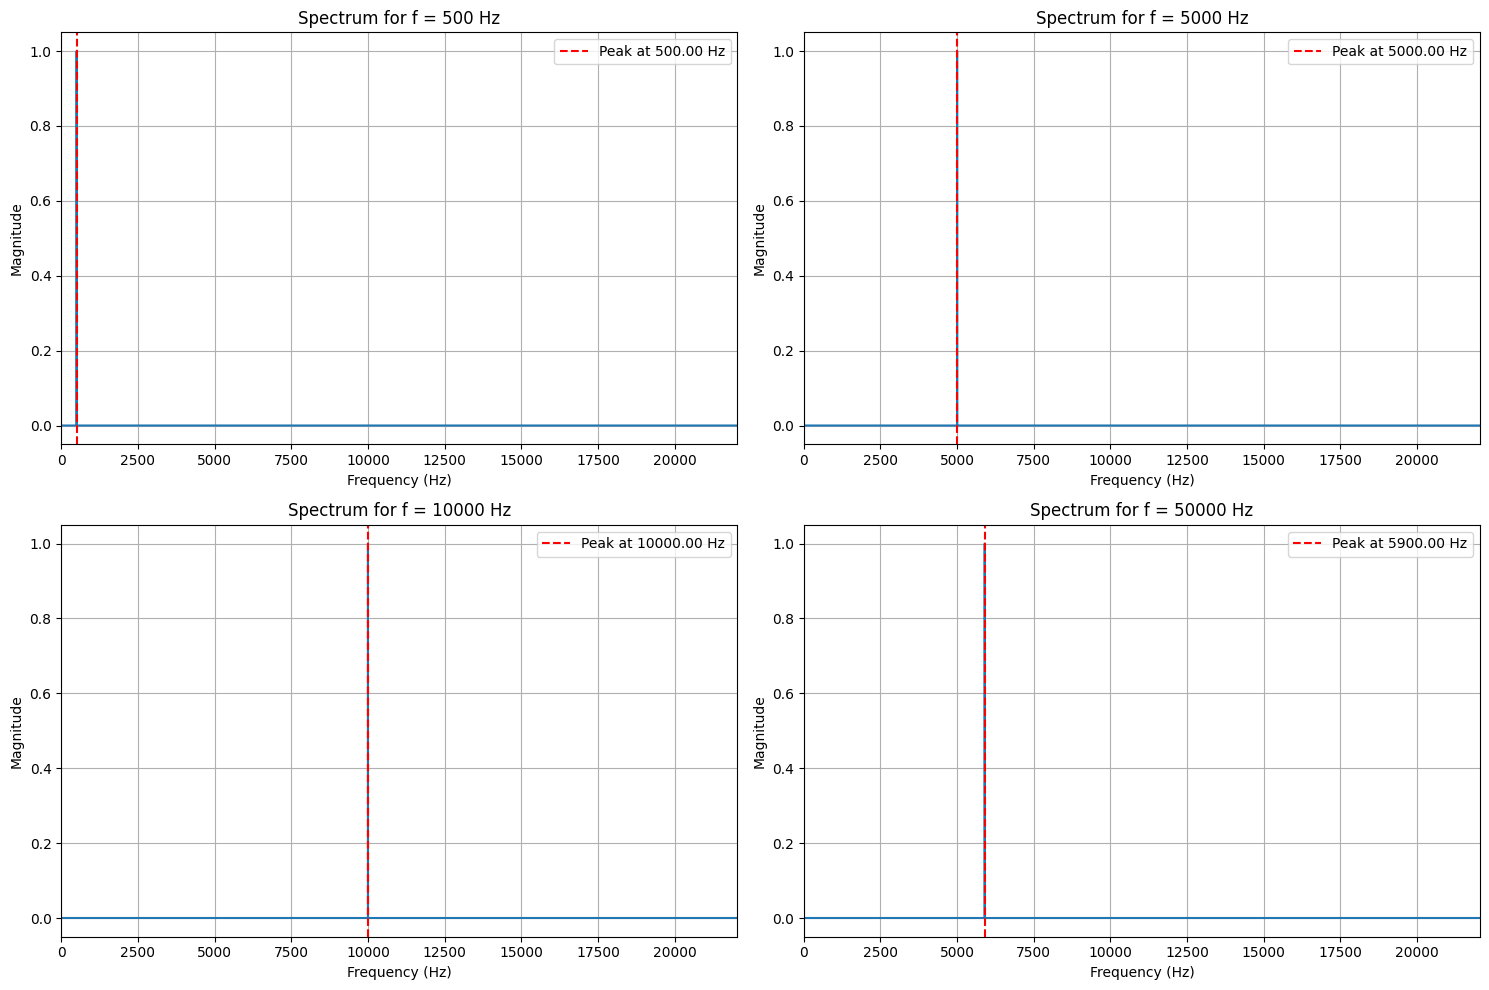

In [ ]:
fs = 44100 # Hz
frequencies_to_test = [500, 5000, 10000, 50000] # Hz

plt.figure(figsize=(15, 10))

for i, f_signal in enumerate(frequencies_to_test):
    freqs, spectrum_magnitude = calculate_spectrum(f_signal, fs)

    plt.subplot(2, 2, i + 1)
    plt.plot(freqs, spectrum_magnitude)
    plt.title(f'Spectrum for f = {f_signal} Hz')
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Magnitude')
    plt.xlim(0, fs / 2) # Show up to Nyquist frequency
    plt.grid(True)

    # Highlight the peak frequency for clearer visualization
    peak_index = np.argmax(spectrum_magnitude)
    peak_freq = freqs[peak_index]
    if peak_freq > 0.001: # Avoid plotting 0 Hz if it's the max for some reason
        plt.axvline(x=peak_freq, color='r', linestyle='--', label=f'Peak at {peak_freq:.2f} Hz')
        plt.legend()

plt.tight_layout()
plt.show()



### Análise dos Espectros:

1.  **Sinais com frequência menor que a frequência de Nyquist (fs/2 = 22.05 kHz):**
    *   Para `f = 500 Hz`, `f = 5000 Hz` e `f = 10000 Hz`, os espectros mostram claramente um pico de magnitude significativo na frequência correspondente do sinal original. Isso ocorre porque essas frequências estão abaixo da frequência de Nyquist (22.05 kHz), o que significa que o sinal foi amostrado adequadamente e sua frequência original pode ser recuperada sem distorções (aliasing).

2.  **Sinal com frequência maior que a frequência de Nyquist (fs/2 = 22.05 kHz):**
    *   Para `f = 50000 Hz`, o espectro não exibe um pico em 50000 Hz. Em vez disso, observamos um pico em `5900 Hz` (conforme indicado pelo `peak_freq` do kernel). Isso é um fenômeno conhecido como **aliasing**.
    *   O aliasing ocorre quando a frequência de amostragem (`fs = 44.1 kHz`) é insuficiente para capturar a frequência real do sinal (`50000 Hz`). A frequência do sinal é 'dobrada' (folded back) para dentro do intervalo de frequências válidas de 0 a `fs/2`. A frequência 'dobrada' pode ser calculada como `|f_sinal - n * fs|`, onde `n` é um número inteiro para que o resultado caia no intervalo `[0, fs/2]`.
    *   Neste caso, para `f_sinal = 50000 Hz` e `fs = 44100 Hz`:
        `|50000 - 1 * 44100| = |50000 - 44100| = 5900 Hz`.
    *   Portanto, o pico observado em 5900 Hz para o sinal de 50000 Hz é uma representação incorreta da frequência original devido à amostragem abaixo da taxa de Nyquist para esta frequência específica. Para evitar aliasing, a frequência de amostragem deve ser pelo menos o dobro da frequência mais alta presente no sinal (Critério de Nyquist).

Questão 2: Para um chirp com frequência inicial f0 = 500 Hz, frequência final f1 = 10000 Hz, amostrado com fs =
44.1 kHz, faça o que se pede nos itens abaixo:


Letra a: Utilizando a função calculate_spectrum(), calcule
o espectro do chirp com varreduras de frequência lineares, quadráticas e logarítmicas.

Os gráficos foram gerados com sucesso! Agora, vamos analisar os espectros obtidos para cada tipo de chirp:

### Análise dos Espectros dos Chirps:

1.  **Chirp Linear:**
    *   No espectro do chirp linear, observamos uma distribuição relativamente uniforme de energia entre a frequência inicial (`f0 = 500 Hz`) e a frequência final (`f1 = 10000 Hz`).
    *   Isso ocorre porque, em um chirp linear, a frequência instantânea do sinal muda de forma constante ao longo do tempo. O FFT, que representa a média das componentes de frequência ao longo de todo o sinal, mostra que todas as frequências dentro do intervalo [500 Hz, 10000 Hz] estão presentes com magnitudes comparáveis.

2.  **Chirp Quadrático:**
    *   Para o chirp quadrático, a frequência instantânea varia quadraticamente com o tempo. Isso significa que o sinal passa mais tempo nas frequências mais baixas do que nas frequências mais altas dentro do intervalo.
    *   No espectro, podemos observar que as magnitudes podem ser ligeiramente maiores nas frequências mais baixas e diminuir gradualmente à medida que as frequências aumentam. Isso reflete o fato de que o sinal permanece por mais tempo nas frequências iniciais da varredura.

3.  **Chirp Logarítmico:**
    *   O chirp logarítmico é projetado para que a frequência instantânea varie logaritmicamente com o tempo. Isso geralmente significa que o sinal passa proporcionalmente mais tempo nas frequências mais altas do que nas frequências mais baixas (em uma escala logarítmica).
    *   No espectro, podemos observar que a energia pode estar mais concentrada nas frequências mais altas do intervalo [500 Hz, 10000 Hz], ou a distribuição pode ser mais nivelada em uma escala logarítmica de frequência. A variação logarítmica é frequentemente usada para emular como o ouvido humano percebe as frequências.

Em geral, para todos os tipos de chirp, o espectro não apresentará um pico único e nítido como um sinal senoidal puro, mas sim uma faixa de frequências, pois o sinal contém múltiplos componentes de frequência que mudam ao longo do tempo. A forma exata da distribuição de magnitude dentro dessa faixa dependerá de como a frequência instantânea varia (linear, quadrática ou logarítmicamente).

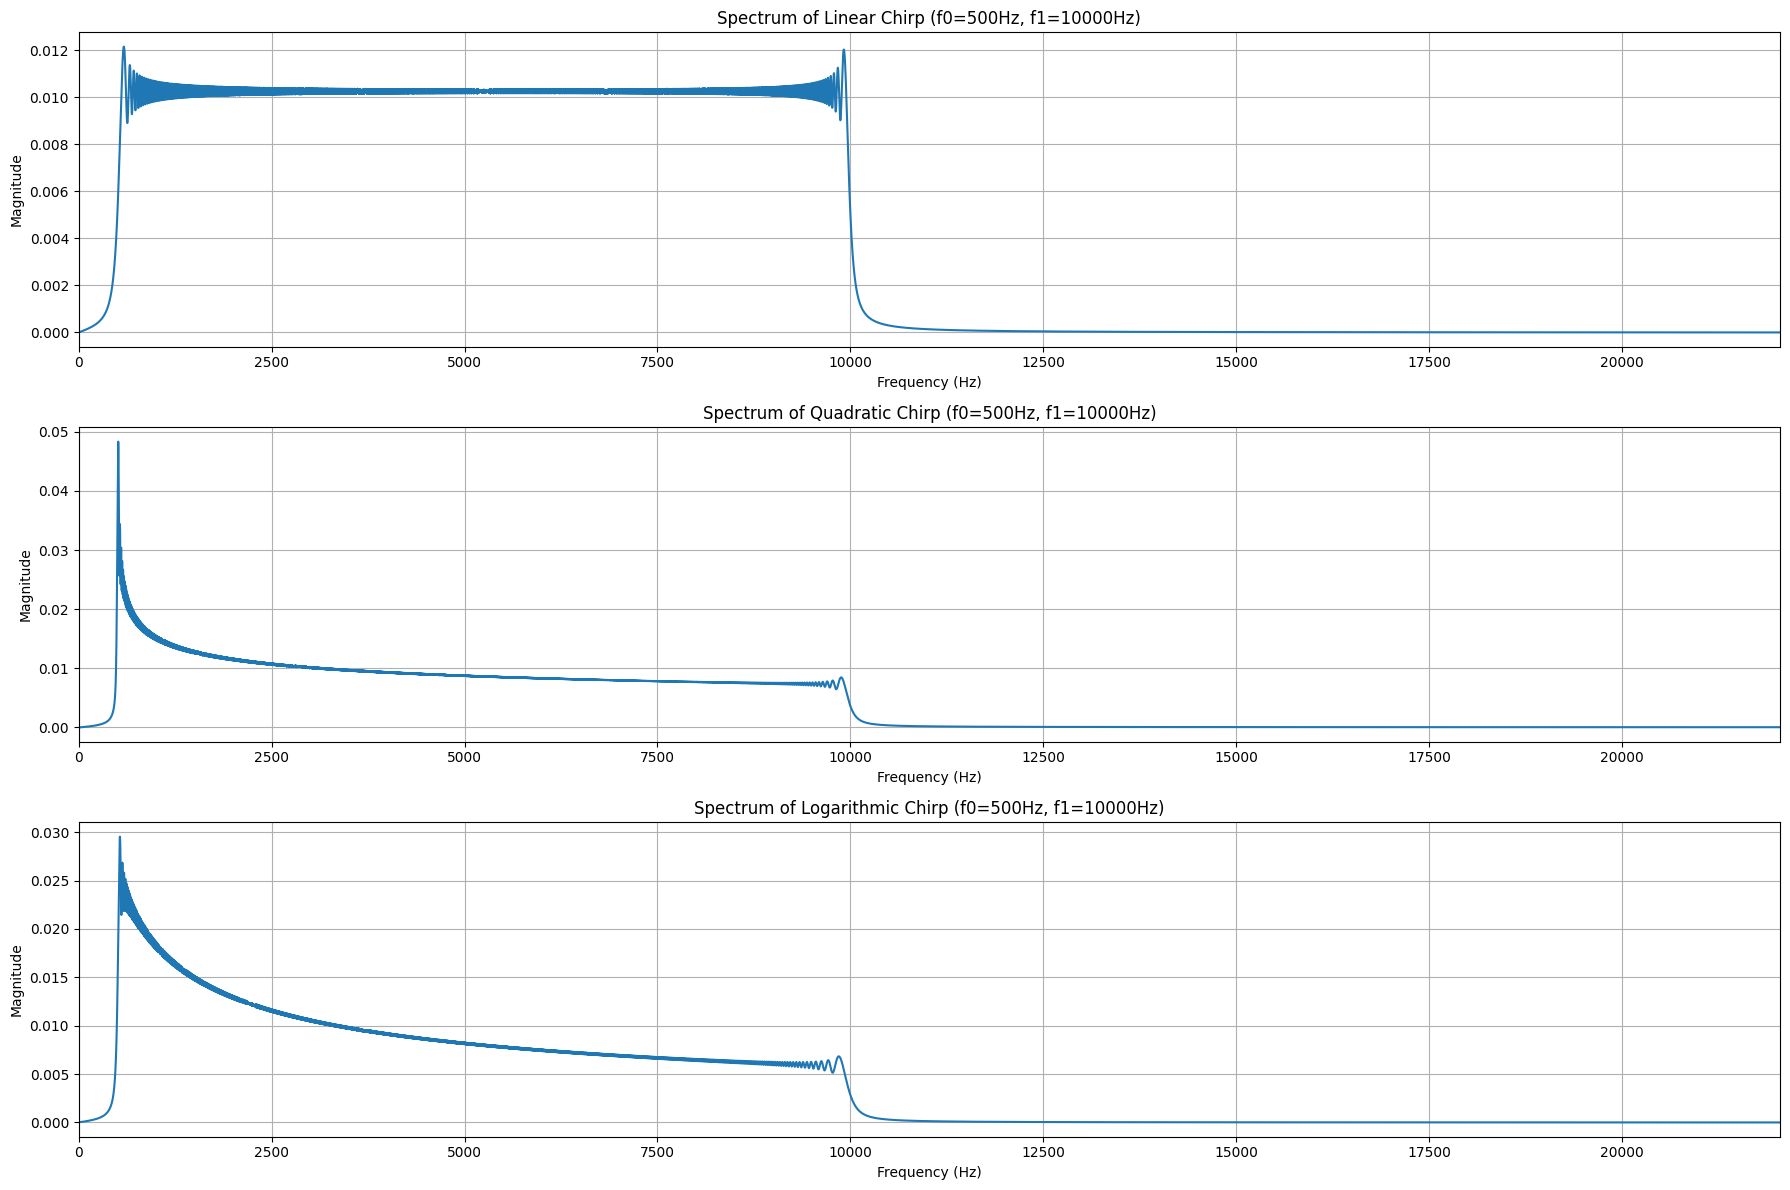

In [36]:
fs = 44100  # Sampling frequency (Hz)
f0 = 500    # Initial frequency (Hz)
f1 = 10000  # Final frequency (Hz)
T = 1.0     # Duration of the chirp (seconds)

t = np.linspace(0, T, int(T * fs), endpoint=False) # Time vector

plt.figure(figsize=(18, 12))

# --- Linear Chirp ---
linear_chirp = chirp(t, f0=f0, f1=f1, t1=T, method='linear')
freqs_linear, spectrum_linear = calculate_spectrum(signal=linear_chirp, fs=fs, duration=T)

plt.subplot(3, 1, 1)
plt.plot(freqs_linear, spectrum_linear)
plt.title('Spectrum of Linear Chirp (f0=500Hz, f1=10000Hz)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.xlim(0, fs / 2)
plt.grid(True)

# --- Quadratic Chirp ---
quadratic_chirp = chirp(t, f0=f0, f1=f1, t1=T, method='quadratic')
freqs_quadratic, spectrum_quadratic = calculate_spectrum(signal=quadratic_chirp, fs=fs, duration=T)

plt.subplot(3, 1, 2)
plt.plot(freqs_quadratic, spectrum_quadratic)
plt.title('Spectrum of Quadratic Chirp (f0=500Hz, f1=10000Hz)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.xlim(0, fs / 2)
plt.grid(True)

# --- Logarithmic Chirp ---
logarithmic_chirp = chirp(t, f0=f0, f1=f1, t1=T, method='logarithmic')
freqs_logarithmic, spectrum_logarithmic = calculate_spectrum(signal=logarithmic_chirp, fs=fs, duration=T)

plt.subplot(3, 1, 3)
plt.plot(freqs_logarithmic, spectrum_logarithmic)
plt.title('Spectrum of Logarithmic Chirp (f0=500Hz, f1=10000Hz)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.xlim(0, fs / 2)
plt.grid(True)

plt.tight_layout()
plt.show()

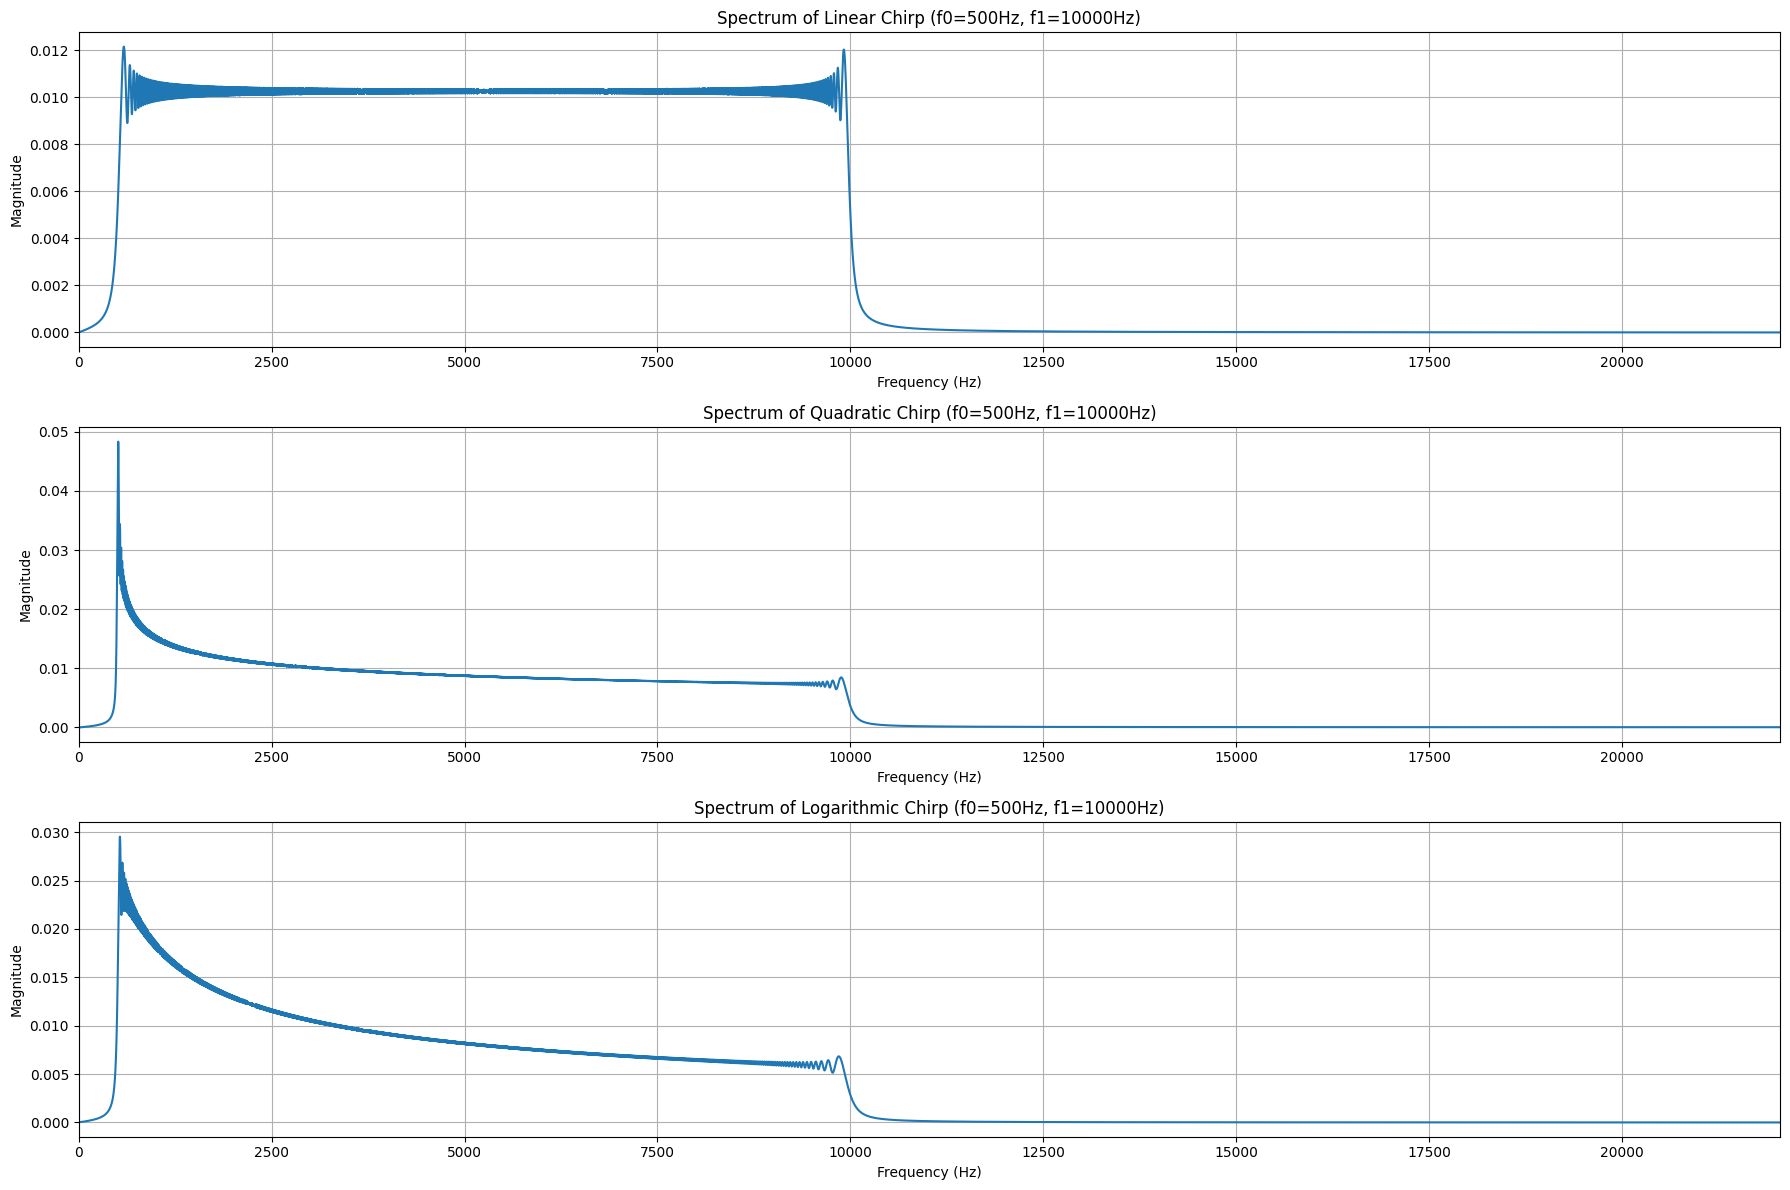

In [ ]:
fs = 44100  # Sampling frequency (Hz)
f0 = 500    # Initial frequency (Hz)
f1 = 10000  # Final frequency (Hz)
T = 1.0     # Duration of the chirp (seconds)

t = np.linspace(0, T, int(T * fs), endpoint=False) # Time vector

plt.figure(figsize=(18, 12))

# --- Linear Chirp ---
linear_chirp = chirp(t, f0=f0, f1=f1, t1=T, method='linear')
freqs_linear, spectrum_linear = calculate_spectrum(signal=linear_chirp, fs=fs, duration=T)

plt.subplot(3, 1, 1)
plt.plot(freqs_linear, spectrum_linear)
plt.title('Spectrum of Linear Chirp (f0=500Hz, f1=10000Hz)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.xlim(0, fs / 2)
plt.grid(True)

# --- Quadratic Chirp ---
quadratic_chirp = chirp(t, f0=f0, f1=f1, t1=T, method='quadratic')
freqs_quadratic, spectrum_quadratic = calculate_spectrum(signal=quadratic_chirp, fs=fs, duration=T)

plt.subplot(3, 1, 2)
plt.plot(freqs_quadratic, spectrum_quadratic)
plt.title('Spectrum of Quadratic Chirp (f0=500Hz, f1=10000Hz)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.xlim(0, fs / 2)
plt.grid(True)

# --- Logarithmic Chirp ---
logarithmic_chirp = chirp(t, f0=f0, f1=f1, t1=T, method='logarithmic')
freqs_logarithmic, spectrum_logarithmic = calculate_spectrum(signal=logarithmic_chirp, fs=fs, duration=T)

plt.subplot(3, 1, 3)
plt.plot(freqs_logarithmic, spectrum_logarithmic)
plt.title('Spectrum of Logarithmic Chirp (f0=500Hz, f1=10000Hz)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.xlim(0, fs / 2)
plt.grid(True)

plt.tight_layout()
plt.show()

Questão 3: Leia o arquivo handel.wav e fala o que se pede nos itens abaixo:


Letra a: Utilizando a função calculate_spectrum(), calcule
o espectro do sinal de áudio.

In [ ]:
def calculate_spectrum(signal, sampling_frequency, single_sided=True):
    """
    Calculates the amplitude spectrum of a signal.

    Args:
        signal (np.ndarray): The time-domain signal.
        sampling_frequency (float): The sampling frequency of the signal (Hz).
        single_sided (bool): If True, returns the single-sided spectrum (positive frequencies).
                             If False, returns the full spectrum (positive and negative frequencies).

    Returns:
        tuple: A tuple containing:
            - frequencies (np.ndarray): Array of frequencies (Hz).
            - amplitudes (np.ndarray): Array of corresponding amplitude magnitudes.
    """
    N = len(signal) # Number of sample points
    T = 1.0 / sampling_frequency # Sample spacing

    # Perform the FFT
    yf = fft(signal)

    if single_sided:
        xf = fftfreq(N, T)[:N//2] # Frequencies for the positive half of the spectrum
        # Calculate the single-sided amplitude spectrum
        # np.abs(yf[0:N//2]) gets the magnitude of the positive frequencies
        amplitudes = 1.0/N * np.abs(yf[0:N//2])
    else:
        xf = fftfreq(N, T) # All frequencies
        amplitudes = 1.0/N * np.abs(yf)

    return xf, amplitudes

In [ ]:
import scipy.io.wavfile as wavfile
import matplotlib.pyplot as plt

# Path to the audio file
audio_file_path = '/content/handel.wav'

# Read the audio file
# This returns the sampling rate (fs) and the signal data (signal)
fs_audio, signal_audio = wavfile.read(audio_file_path)

print(f"Sampling frequency of handel.wav: {fs_audio} Hz")
print(f"Number of samples in handel.wav: {len(signal_audio)}")


Sampling frequency of handel.wav: 8192 Hz
Number of samples in handel.wav: 73113


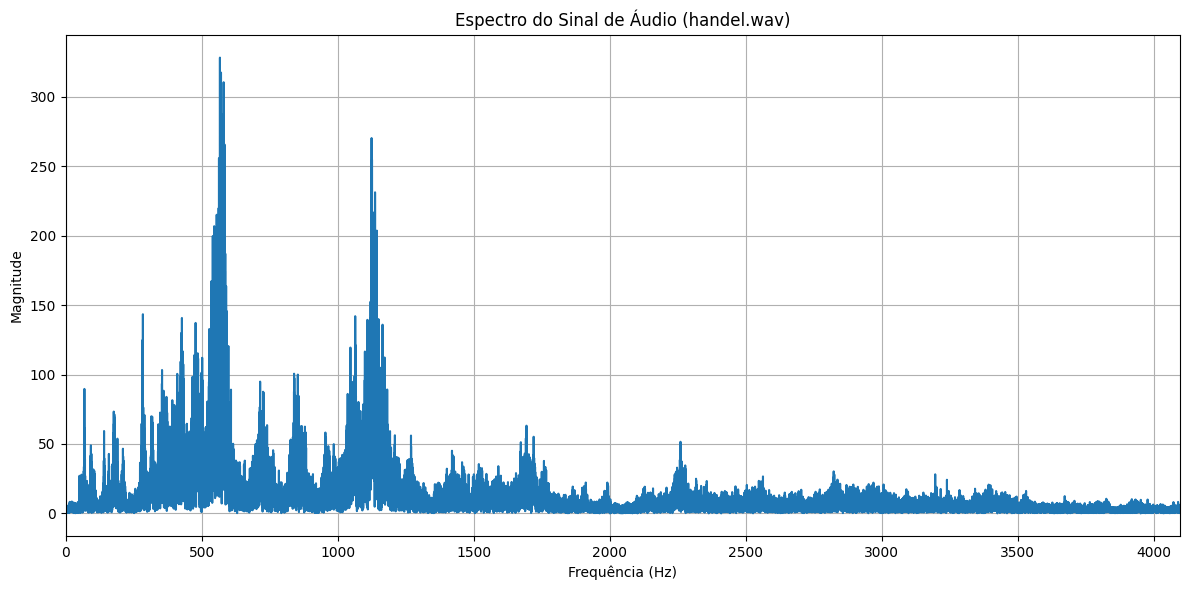

In [ ]:
import numpy as np
from scipy.fft import fft, fftfreq

def calculate_spectrum(signal, sampling_frequency, single_sided=True):
    """
    Calculates the amplitude spectrum of a signal.

    Args:
        signal (np.ndarray): The time-domain signal.
        sampling_frequency (float): The sampling frequency of the signal (Hz).
        single_sided (bool): If True, returns the single-sided spectrum (positive frequencies).
                             If False, returns the full spectrum (positive and negative frequencies).

    Returns:
        tuple: A tuple containing:
            - frequencies (np.ndarray): Array of frequencies (Hz).
            - amplitudes (np.ndarray): Array of corresponding amplitude magnitudes.
    """
    N = len(signal) # Number of sample points
    T = 1.0 / sampling_frequency # Sample spacing

    # Perform the FFT
    yf = fft(signal)

    if single_sided:
        xf = fftfreq(N, T)[:N//2] # Frequencies for the positive half of the spectrum
        # Calculate the single-sided amplitude spectrum
        # np.abs(yf[0:N//2]) gets the magnitude of the positive frequencies
        amplitudes = 1.0/N * np.abs(yf[0:N//2])
    else:
        xf = fftfreq(N, T) # All frequencies
        amplitudes = 1.0/N * np.abs(yf)

    return xf, amplitudes

# Calculate the spectrum using the provided function
freqs_audio, spectrum_audio = calculate_spectrum(signal_audio, fs_audio)

# Plot the spectrum
plt.figure(figsize=(12, 6))
plt.plot(freqs_audio, spectrum_audio)
plt.title('Espectro do Sinal de Áudio (handel.wav)')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Magnitude')
plt.xlim(0, fs_audio / 2) # Show up to Nyquist frequency
plt.grid(True)
plt.tight_layout()
plt.show()


Questão 4) Subamostrar um sinal x[n] por um fator de M ´e o
mesmo que reduzir sua taxa de amostragem em M vezes.
A rela¸c˜ao entre o sinal subamostrado e o sinal original ´e
dada por
y[n] = x[nM].
Para o arquivo handel.wav, fa¸ca o que se pede nos itens
abaixo:

(a) Crie uma fun¸c˜ao para realizar a subamostragem de
um sinal discreto.


In [ ]:
import numpy as np

def downsample_signal(signal, M):
    """
    Realiza a subamostragem (downsampling) de um sinal discreto por um fator M.
    A relação é dada por y[n] = x[nM].

    Args:
        signal (np.ndarray): O sinal discreto original.
        M (int): O fator de subamostragem. Deve ser um inteiro positivo.

    Returns:
        np.ndarray: O sinal subamostrado.
    """
    if not isinstance(M, int) or M <= 0:
        raise ValueError("O fator de subamostragem M deve ser um inteiro positivo.")

    # Seleciona cada M-ésima amostra do sinal original
    downsampled_signal = signal[::M]
    return downsampled_signal

print("Função downsample_signal criada com sucesso!")


Função downsample_signal criada com sucesso!


In [ ]:
# Fator de subamostragem (exemplo: M = 2)
M_downsample = 2

# Aplica a função de subamostragem ao sinal de áudio original
downsampled_signal_audio = downsample_signal(signal_audio, M=M_downsample)

# A nova frequência de amostragem será fs_audio / M
new_fs_audio = fs_audio / M_downsample

print(f"Tamanho do sinal original: {len(signal_audio)} amostras")
print(f"Frequência de amostragem original: {fs_audio} Hz")
print(f"Fator de subamostragem M: {M_downsample}")
print(f"Tamanho do sinal subamostrado: {len(downsampled_signal_audio)} amostras")
print(f"Nova frequência de amostragem: {new_fs_audio} Hz")


Tamanho do sinal original: 73113 amostras
Frequência de amostragem original: 8192 Hz
Fator de subamostragem M: 2
Tamanho do sinal subamostrado: 36557 amostras
Nova frequência de amostragem: 4096.0 Hz


In [ ]:
downsample_factors = [2, 4, 8]

print(f"Tamanho do sinal original: {len(signal_audio)} amostras")
print(f"Frequência de amostragem original: {fs_audio} Hz\n")

for M_downsample in downsample_factors:
    print(f"=== Subamostrando com M = {M_downsample} ===")
    # Aplica a função de subamostragem ao sinal de áudio original
    downsampled_signal = downsample_signal(signal_audio, M=M_downsample)

    # A nova frequência de amostragem será fs_audio / M
    new_fs = fs_audio / M_downsample

    print(f"Tamanho do sinal subamostrado: {len(downsampled_signal)} amostras")
    print(f"Nova frequência de amostragem: {new_fs} Hz")
    print("\n")


Tamanho do sinal original: 73113 amostras
Frequência de amostragem original: 8192 Hz

=== Subamostrando com M = 2 ===
Tamanho do sinal subamostrado: 36557 amostras
Nova frequência de amostragem: 4096.0 Hz


=== Subamostrando com M = 4 ===
Tamanho do sinal subamostrado: 18279 amostras
Nova frequência de amostragem: 2048.0 Hz


=== Subamostrando com M = 8 ===
Tamanho do sinal subamostrado: 9140 amostras
Nova frequência de amostragem: 1024.0 Hz




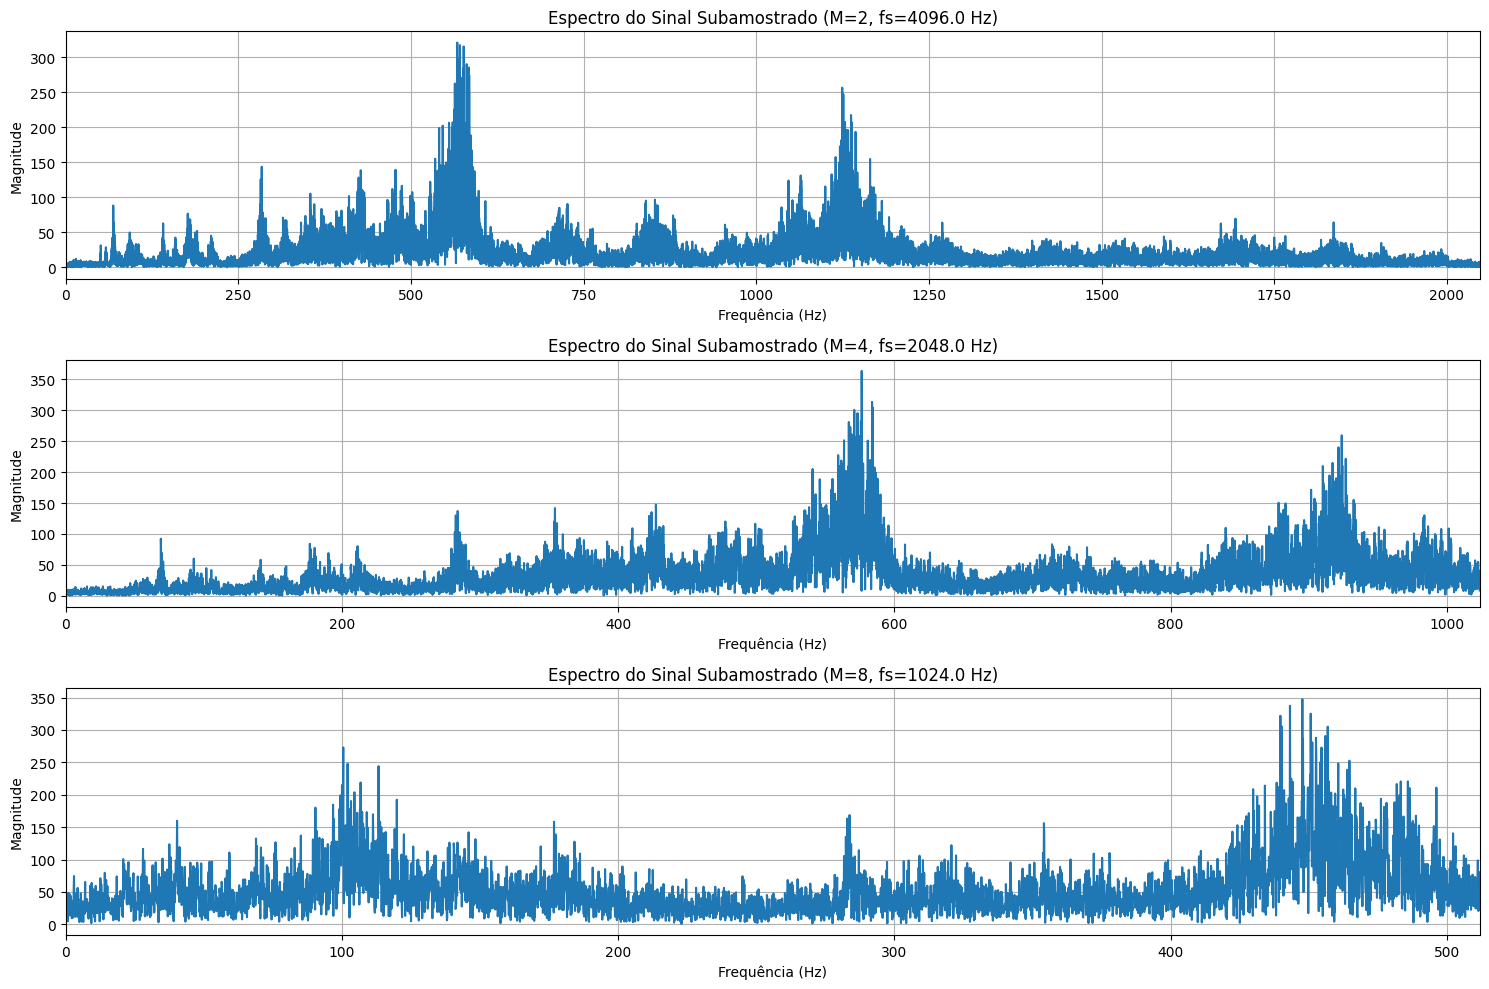

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq

def calculate_spectrum(signal, sampling_frequency, single_sided=True):
    """
    Calculates the amplitude spectrum of a signal.

    Args:
        signal (np.ndarray): The time-domain signal.
        sampling_frequency (float): The sampling frequency of the signal (Hz).
        single_sided (bool): If True, returns the single-sided spectrum (positive frequencies).
                             If False, returns the full spectrum (positive and negative frequencies).

    Returns:
        tuple: A tuple containing:
            - frequencies (np.ndarray): Array of frequencies (Hz).
            - amplitudes (np.ndarray): Array of corresponding amplitude magnitudes.
    """
    N = len(signal) # Number of sample points
    T = 1.0 / sampling_frequency # Sample spacing

    # Perform the FFT
    yf = fft(signal)

    if single_sided:
        xf = fftfreq(N, T)[:N//2] # Frequencies for the positive half of the spectrum
        # Calculate the single-sided amplitude spectrum
        # np.abs(yf[0:N//2]) gets the magnitude of the positive frequencies
        amplitudes = 1.0/N * np.abs(yf[0:N//2])
    else:
        xf = fftfreq(N, T) # All frequencies
        amplitudes = 1.0/N * np.abs(yf)

    return xf, amplitudes


def downsample_signal(signal, M):
    """
    Realiza a subamostragem (downsampling) de um sinal discreto por um fator M.
    A relação é dada por y[n] = x[nM].

    Args:
        signal (np.ndarray): O sinal discreto original.
        M (int): O fator de subamostragem. Deve ser um inteiro positivo.

    Returns:
        np.ndarray: O sinal subamostrado.
    """
    if not isinstance(M, int) or M <= 0:
        raise ValueError("O fator de subamostragem M deve ser um inteiro positivo.")

    # Seleciona cada M-ésima amostra do sinal original
    downsampled_signal = signal[::M]
    return downsampled_signal


downsample_factors = [2, 4, 8]

plt.figure(figsize=(15, 10))

for i, M_downsample in enumerate(downsample_factors):
    # Aplica a função de subamostragem ao sinal de áudio original
    downsampled_signal = downsample_signal(signal_audio, M=M_downsample)

    # A nova frequência de amostragem será fs_audio / M
    new_fs = fs_audio / M_downsample

    # Calcula o espectro do sinal subamostrado
    freqs_downsampled, spectrum_downsampled = calculate_spectrum(downsampled_signal, new_fs)

    # Plot the spectrum
    plt.subplot(len(downsample_factors), 1, i + 1)
    plt.plot(freqs_downsampled, spectrum_downsampled)
    plt.title(f'Espectro do Sinal Subamostrado (M={M_downsample}, fs={new_fs:.1f} Hz)')
    plt.xlabel('Frequência (Hz)')
    plt.ylabel('Magnitude')
    plt.xlim(0, new_fs / 2) # Show up to Nyquist frequency of the downsampled signal
    plt.grid(True)

plt.tight_layout()
plt.show()


Agora você pode analisar os espectros dos sinais subamostrados e observar as diferenças em relação ao sinal original, especialmente em termos da frequência de Nyquist e da presença de possível aliasing.

In [ ]:
import scipy.io.wavfile as wavfile
import numpy as np

def downsample_signal(signal, M):
    """
    Realiza a subamostragem (downsampling) de um sinal discreto por um fator M.
    A relação é dada por y[n] = x[nM].

    Args:
        signal (np.ndarray): O sinal discreto original.
        M (int): O fator de subamostragem. Deve ser um inteiro positivo.

    Returns:
        np.ndarray: O sinal subamostrado.
    """
    if not isinstance(M, int) or M <= 0:
        raise ValueError("O fator de subamostragem M deve ser um inteiro positivo.")

    # Seleciona cada M-ésima amostra do sinal original
    downsampled_signal = signal[::M]
    return downsampled_signal

downsample_factors = [2, 4, 8]

print("Gerando arquivos de áudio subamostrados...")

for M_downsample in downsample_factors:
    # Aplica a função de subamostragem ao sinal de áudio original
    downsampled_signal = downsample_signal(signal_audio, M=M_downsample)

    # A nova frequência de amostragem será fs_audio / M
    new_fs = int(fs_audio / M_downsample)

    # Certifica-se de que o sinal está no formato correto para wav (int16)
    # Se o sinal original for int16, a subamostragem não mudará o tipo.
    # Se for de outro tipo, pode ser necessário converter. Assume-se int16 aqui.
    if downsampled_signal.dtype != np.int16:
        downsampled_signal = downsampled_signal.astype(np.int16)

    output_filename = f'/content/handel_downsampled_M{M_downsample}.wav'
    wavfile.write(output_filename, new_fs, downsampled_signal)
    print(f'Arquivo gerado: {output_filename} com fs = {new_fs} Hz')

print("Processo concluído. Você pode encontrar os arquivos .wav na pasta /content.")


Gerando arquivos de áudio subamostrados...
Arquivo gerado: /content/handel_downsampled_M2.wav com fs = 4096 Hz
Arquivo gerado: /content/handel_downsampled_M4.wav com fs = 2048 Hz
Arquivo gerado: /content/handel_downsampled_M8.wav com fs = 1024 Hz
Processo concluído. Você pode encontrar os arquivos .wav na pasta /content.


Os arquivos de áudio subamostrados foram gerados e salvos na pasta `/content/`. Você pode baixá-los e ouvi-los para perceber o efeito da subamostragem.

Você pode agora usar `downsampled_signal_audio` e `new_fs_audio` para, por exemplo, ouvir o áudio subamostrado ou calcular seu novo espectro.

QUESTÃO 5) Repita a questão anterior utilizando a função scipy.signal.resample() e compare os resultados obtidos utilizando a sua função.

(a) Crie uma fun¸c˜ao para realizar a subamostragem de
um sinal discreto.


In [10]:
import numpy as np
from scipy.signal import resample

def downsample_resample_signal(signal, original_fs, M):
    """
    Downsamples a discrete signal by a factor M using scipy.signal.resample().

    Args:
        signal (np.ndarray): The discrete signal to be downsampled.
        original_fs (float): The original sampling frequency of the signal.
        M (int): The downsampling factor.

    Returns:
        tuple: A tuple containing:
            - resampled_signal (np.ndarray): The downsampled signal.
            - new_fs (float): The new sampling frequency.
    """
    if not isinstance(M, int) or M <= 0:
        raise ValueError("The downsampling factor M must be a positive integer.")

    # Calculate the number of samples for the resampled signal
    num_samples_resampled = len(signal) // M

    # Use scipy.signal.resample to resample the signal
    # Note: resample changes the number of samples, effectively changing the sampling rate
    resampled_signal = resample(signal, num_samples_resampled)

    # Calculate the new sampling frequency
    new_fs = original_fs / M

    return resampled_signal, new_fs

print("Function 'downsample_resample_signal' created successfully!")

Function 'downsample_resample_signal' created successfully!


(b) Utilizando a fun¸c˜ao criada, realize a subamostragem
do sinal de ´audio por fator de M ∈ {2, 4, 8}.


In [13]:
import scipy.io.wavfile as wavfile

# Path to the audio file
audio_file_path = '/content/drive/MyDrive/Audios prática 2 - Proc Sin 1/Questão 4/handel.wav'

# Read the audio file to ensure signal_audio and fs_audio are defined
fs_audio, signal_audio = wavfile.read(audio_file_path)

downsample_factors = [2, 4, 8]
resampled_data_resample = {}

print(f"Original signal length: {len(signal_audio)} samples")
print(f"Original sampling frequency: {fs_audio} Hz\n")

for M in downsample_factors:
    print(f"=== Downsampling with M = {M} (using scipy.signal.resample) ===")
    resampled_signal, new_fs = downsample_resample_signal(signal_audio, fs_audio, M)
    resampled_data_resample[M] = {
        'signal': resampled_signal,
        'fs': new_fs
    }

    print(f"Length of resampled signal: {len(resampled_signal)} samples")
    print(f"New sampling frequency: {new_fs:.1f} Hz")
    print("\n")

print("Downsampling with scipy.signal.resample completed for all factors.")

Original signal length: 73113 samples
Original sampling frequency: 8192 Hz

=== Downsampling with M = 2 (using scipy.signal.resample) ===
Length of resampled signal: 36556 samples
New sampling frequency: 4096.0 Hz


=== Downsampling with M = 4 (using scipy.signal.resample) ===
Length of resampled signal: 18278 samples
New sampling frequency: 2048.0 Hz


=== Downsampling with M = 8 (using scipy.signal.resample) ===
Length of resampled signal: 9139 samples
New sampling frequency: 1024.0 Hz


Downsampling with scipy.signal.resample completed for all factors.


 (c) Utilizando a função scipy.signal.resample(), calcule
o espectro do sinal subamostrado.



In [27]:
print("\n--- Displaying Resampling Results (scipy.signal.resample) ---")
for M, data in resampled_data_resample.items():
    resampled_signal = data['signal']
    new_fs = data['fs']
    print(f"For M = {M}:")
    print(f"  Length of resampled signal: {len(resampled_signal)} samples")
    print(f"  New sampling frequency: {new_fs:.1f} Hz")
    print("\n")


--- Displaying Resampling Results (scipy.signal.resample) ---
For M = 2:
  Length of resampled signal: 36556 samples
  New sampling frequency: 4096.0 Hz


For M = 4:
  Length of resampled signal: 18278 samples
  New sampling frequency: 2048.0 Hz


For M = 8:
  Length of resampled signal: 9139 samples
  New sampling frequency: 1024.0 Hz




## Compare with Simple Downsampling

### Subtask:
Re-display the characteristics (length and new sampling frequency) of the signals downsampled using the custom `downsample_signal` function (y[n] = x[nM]) for M = 2, 4, and 8, for direct comparison with the `scipy.signal.resample()` results.


**Reasoning**:
I need to re-display the characteristics of signals downsampled using the custom `downsample_signal` function. I will initialize a dictionary to store the results, iterate through the downsampling factors, apply the custom function, calculate the new sampling frequency, and then print the length and new sampling frequency for each downsampled signal.



In [28]:
import numpy as np

def downsample_signal(signal, M):
    """
    Realiza a subamostragem (downsampling) de um sinal discreto por um fator M.
    A relação é dada por y[n] = x[nM].

    Args:
        signal (np.ndarray): O sinal discreto original.
        M (int): O fator de subamostragem. Deve ser um inteiro positivo.

    Returns:
        np.ndarray: O sinal subamostrado.
    """
    if not isinstance(M, int) or M <= 0:
        raise ValueError("O fator de subamostragem M deve ser um inteiro positivo.")

    # Seleciona cada M-ésima amostra do sinal original
    downsampled_signal = signal[::M]
    return downsampled_signal

downsample_factors = [2, 4, 8]
downsampled_data_custom = {}

print(f"Original signal length: {len(signal_audio)} samples")
print(f"Original sampling frequency: {fs_audio} Hz\n")

print("--- Results using custom downsample_signal function (y[n] = x[nM]) ---")
for M in downsample_factors:
    print(f"=== Downsampling with M = {M} ===")
    # Apply the custom downsampling function
    downsampled_signal = downsample_signal(signal_audio, M=M)

    # Calculate the new sampling frequency
    new_fs = fs_audio / M

    downsampled_data_custom[M] = {
        'signal': downsampled_signal,
        'fs': new_fs
    }

    print(f"Length of downsampled signal: {len(downsampled_signal)} samples")
    print(f"New sampling frequency: {new_fs:.1f} Hz")
    print("\n")


Original signal length: 73113 samples
Original sampling frequency: 8192 Hz

--- Results using custom downsample_signal function (y[n] = x[nM]) ---
=== Downsampling with M = 2 ===
Length of downsampled signal: 36557 samples
New sampling frequency: 4096.0 Hz


=== Downsampling with M = 4 ===
Length of downsampled signal: 18279 samples
New sampling frequency: 2048.0 Hz


=== Downsampling with M = 8 ===
Length of downsampled signal: 9140 samples
New sampling frequency: 1024.0 Hz




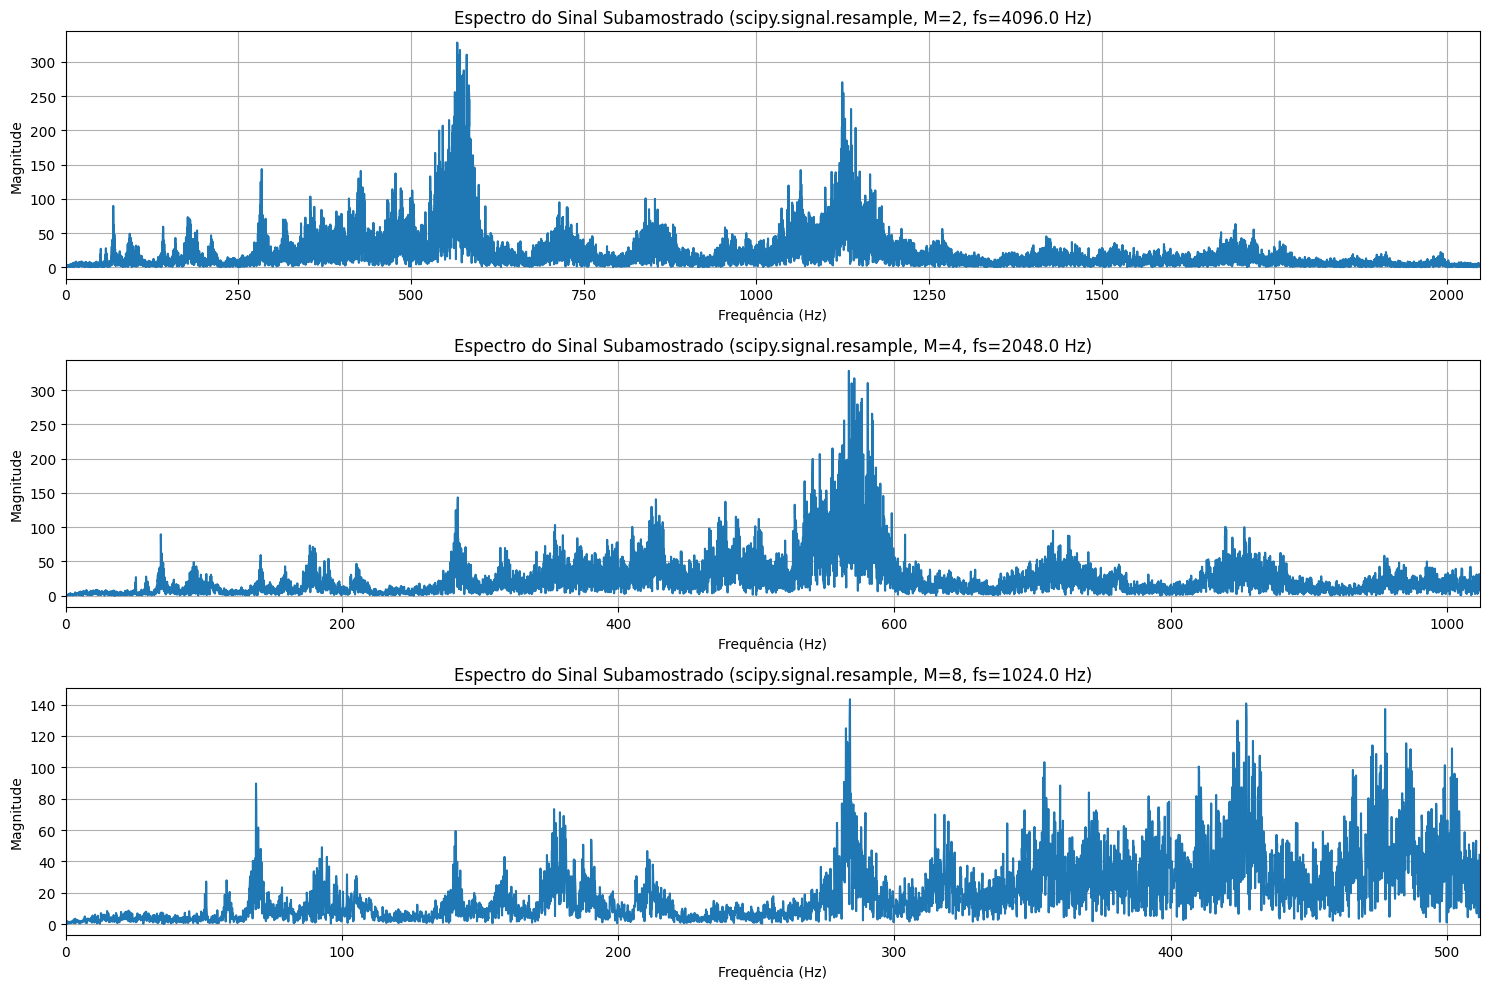

In [17]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.fft import fft, fftfreq

# Ensure calculate_spectrum is available. It was defined in cell 0b5f1d45.
# Copying it here to make the cell self-contained for execution if needed.
# In a real notebook, one might rely on its prior definition.

def calculate_spectrum(signal, sampling_frequency, single_sided=True):
    """
    Calculates the amplitude spectrum of a signal.

    Args:
        signal (np.ndarray): The time-domain signal.
        sampling_frequency (float): The sampling frequency of the signal (Hz).
        single_sided (bool): If True, returns the single-sided spectrum (positive frequencies).
                             If False, returns the full spectrum (positive and negative frequencies).

    Returns:
        tuple: A tuple containing:
            - frequencies (np.ndarray): Array of frequencies (Hz).
            - amplitudes (np.ndarray): Array of corresponding amplitude magnitudes.
    """
    N = len(signal) # Number of sample points
    T = 1.0 / sampling_frequency # Sample spacing

    # Perform the FFT
    yf = fft(signal)

    if single_sided:
        xf = fftfreq(N, T)[:N//2] # Frequencies for the positive half of the spectrum
        # Calculate the single-sided amplitude spectrum
        # np.abs(yf[0:N//2]) gets the magnitude of the positive frequencies
        amplitudes = 1.0/N * np.abs(yf[0:N//2])
    else:
        xf = fftfreq(N, T) # All frequencies
        amplitudes = 1.0/N * np.abs(yf)

    return xf, amplitudes

plt.figure(figsize=(15, 10))

# Assuming resampled_data_resample and fs_audio are available from previous cells
# Re-sort the keys to ensure plots are in order M=2, M=4, M=8
sorted_downsample_factors = sorted(resampled_data_resample.keys())

for i, M in enumerate(sorted_downsample_factors):
    data = resampled_data_resample[M]
    resampled_signal = data['signal']
    new_fs = data['fs']

    # Calculate the spectrum of the resampled signal
    freqs_resampled, spectrum_resampled = calculate_spectrum(resampled_signal, new_fs)

    # Create a subplot for the current downsampling factor
    plt.subplot(len(sorted_downsample_factors), 1, i + 1)
    plt.plot(freqs_resampled, spectrum_resampled)
    plt.title(f'Espectro do Sinal Subamostrado (scipy.signal.resample, M={M}, fs={new_fs:.1f} Hz)')
    plt.xlabel('Frequência (Hz)')
    plt.ylabel('Magnitude')
    plt.xlim(0, new_fs / 2) # Show up to Nyquist frequency of the resampled signal
    plt.grid(True)

plt.tight_layout()
plt.show()


(d) audios




In [18]:
import scipy.io.wavfile as wavfile
import numpy as np
from scipy.signal import resample

# Ensure the downsample_resample_signal function is defined (copied from previous relevant cell)
def downsample_resample_signal(signal, original_fs, M):
    """
    Downsamples a discrete signal by a factor M using scipy.signal.resample().

    Args:
        signal (np.ndarray): The discrete signal to be downsampled.
        original_fs (float): The original sampling frequency of the signal.
        M (int): The downsampling factor.

    Returns:
        tuple: A tuple containing:
            - resampled_signal (np.ndarray): The downsampled signal.
            - new_fs (float): The new sampling frequency.
    """
    if not isinstance(M, int) or M <= 0:
        raise ValueError("The downsampling factor M must be a positive integer.")

    # Calculate the number of samples for the resampled signal
    num_samples_resampled = len(signal) // M

    # Use scipy.signal.resample to resample the signal
    resampled_signal = resample(signal, num_samples_resampled)

    # Calculate the new sampling frequency
    new_fs = original_fs / M

    return resampled_signal, new_fs


# Ensure fs_audio and signal_audio are loaded (assuming they are from previous cells or reload if necessary)
# For robustness, we'll reload it here if it might not be present from prior execution context in this specific run
try:
    if 'signal_audio' not in locals() or 'fs_audio' not in locals():
        audio_file_path = '/content/drive/MyDrive/Audios prática 2 - Proc Sin 1/Questão 4/handel.wav'
        fs_audio, signal_audio = wavfile.read(audio_file_path)
except FileNotFoundError:
    print("Error: handel.wav not found. Please ensure it's loaded in a previous step or available at the specified path.")


downsample_factors = [2, 4, 8]

print("Gerando arquivos de áudio subamostrados usando scipy.signal.resample()...")

for M_downsample in downsample_factors:
    # Aplica a função de subamostragem ao sinal de áudio original
    resampled_signal, new_fs = downsample_resample_signal(signal_audio, fs_audio, M=M_downsample)

    # Converte o sinal para o tipo int16, se necessário, para salvar como WAV
    # scipy.signal.resample can return float, so conversion is crucial
    if resampled_signal.dtype != np.int16:
        # Scale to original range if the signal was float (e.g., from -1 to 1)
        # If original signal was int16, it's typically within +/- 32767
        # We'll assume scaling for 16-bit audio range if it's float
        if np.issubdtype(resampled_signal.dtype, np.floating):
            # Find the max absolute value in the original signal for scaling
            max_val_original = np.iinfo(signal_audio.dtype).max if np.issubdtype(signal_audio.dtype, np.integer) else 1.0
            # Scale and convert to int16
            resampled_signal = (resampled_signal / np.max(np.abs(resampled_signal)) * max_val_original).astype(np.int16)
        else:
            resampled_signal = resampled_signal.astype(np.int16)

    output_filename = f'/content/handel_resampled_scipy_M{M_downsample}.wav'
    wavfile.write(output_filename, int(new_fs), resampled_signal)
    print(f'Arquivo gerado: {output_filename} com fs = {int(new_fs)} Hz')

print("Processo concluído. Você pode encontrar os arquivos .wav na pasta /content.")

Gerando arquivos de áudio subamostrados usando scipy.signal.resample()...
Arquivo gerado: /content/handel_resampled_scipy_M2.wav com fs = 4096 Hz
Arquivo gerado: /content/handel_resampled_scipy_M4.wav com fs = 2048 Hz
Arquivo gerado: /content/handel_resampled_scipy_M8.wav com fs = 1024 Hz
Processo concluído. Você pode encontrar os arquivos .wav na pasta /content.


Questão 6 (a)

In [30]:
import numpy as np

def oversample_signal(signal, L):
    """
    Oversamples a discrete signal by inserting L-1 zeros between each sample.

    Args:
        signal (np.ndarray): The discrete signal to be oversampled.
        L (int): The oversampling factor. Must be a positive integer.

    Returns:
        np.ndarray: The oversampled signal.
    """
    if not isinstance(L, int) or L <= 0:
        raise ValueError("The oversampling factor L must be a positive integer.")

    # Calculate the length of the oversampled signal
    oversampled_length = len(signal) * L

    # Create a new array initialized with zeros
    oversampled_signal = np.zeros(oversampled_length, dtype=signal.dtype)

    # Place each sample of the original signal at every L-th position
    oversampled_signal[::L] = signal

    return oversampled_signal

print("Function 'oversample_signal' created successfully!")

Function 'oversample_signal' created successfully!


Item b)  Utilizando a função criada, realize a sobreamostragem do sinal de áudio por um fator de M ∈ {2, 4, 8}.


In [31]:
oversample_factors = [2, 4, 8]
oversampled_data = {}

print(f"Original signal length: {len(signal_audio)} samples")
print(f"Original sampling frequency: {fs_audio} Hz\n")

for L_oversample in oversample_factors:
    print(f"=== Oversampling with L = {L_oversample} ===")
    # Apply the oversampling function to the audio signal
    oversampled_signal = oversample_signal(signal_audio, L=L_oversample)

    # The new sampling frequency will be fs_audio * L
    new_fs = fs_audio * L_oversample

    oversampled_data[L_oversample] = {
        'signal': oversampled_signal,
        'fs': new_fs
    }

    print(f"Length of oversampled signal: {len(oversampled_signal)} samples")
    print(f"New sampling frequency: {new_fs} Hz")
    print("\n")

print("Oversampling completed for all factors.")

Original signal length: 73113 samples
Original sampling frequency: 8192 Hz

=== Oversampling with L = 2 ===
Length of oversampled signal: 146226 samples
New sampling frequency: 16384 Hz


=== Oversampling with L = 4 ===
Length of oversampled signal: 292452 samples
New sampling frequency: 32768 Hz


=== Oversampling with L = 8 ===
Length of oversampled signal: 584904 samples
New sampling frequency: 65536 Hz


Oversampling completed for all factors.


Item c)  Utilizando a função calculate_spectrum(), calcule o espectro do sinal sobreamostrado.

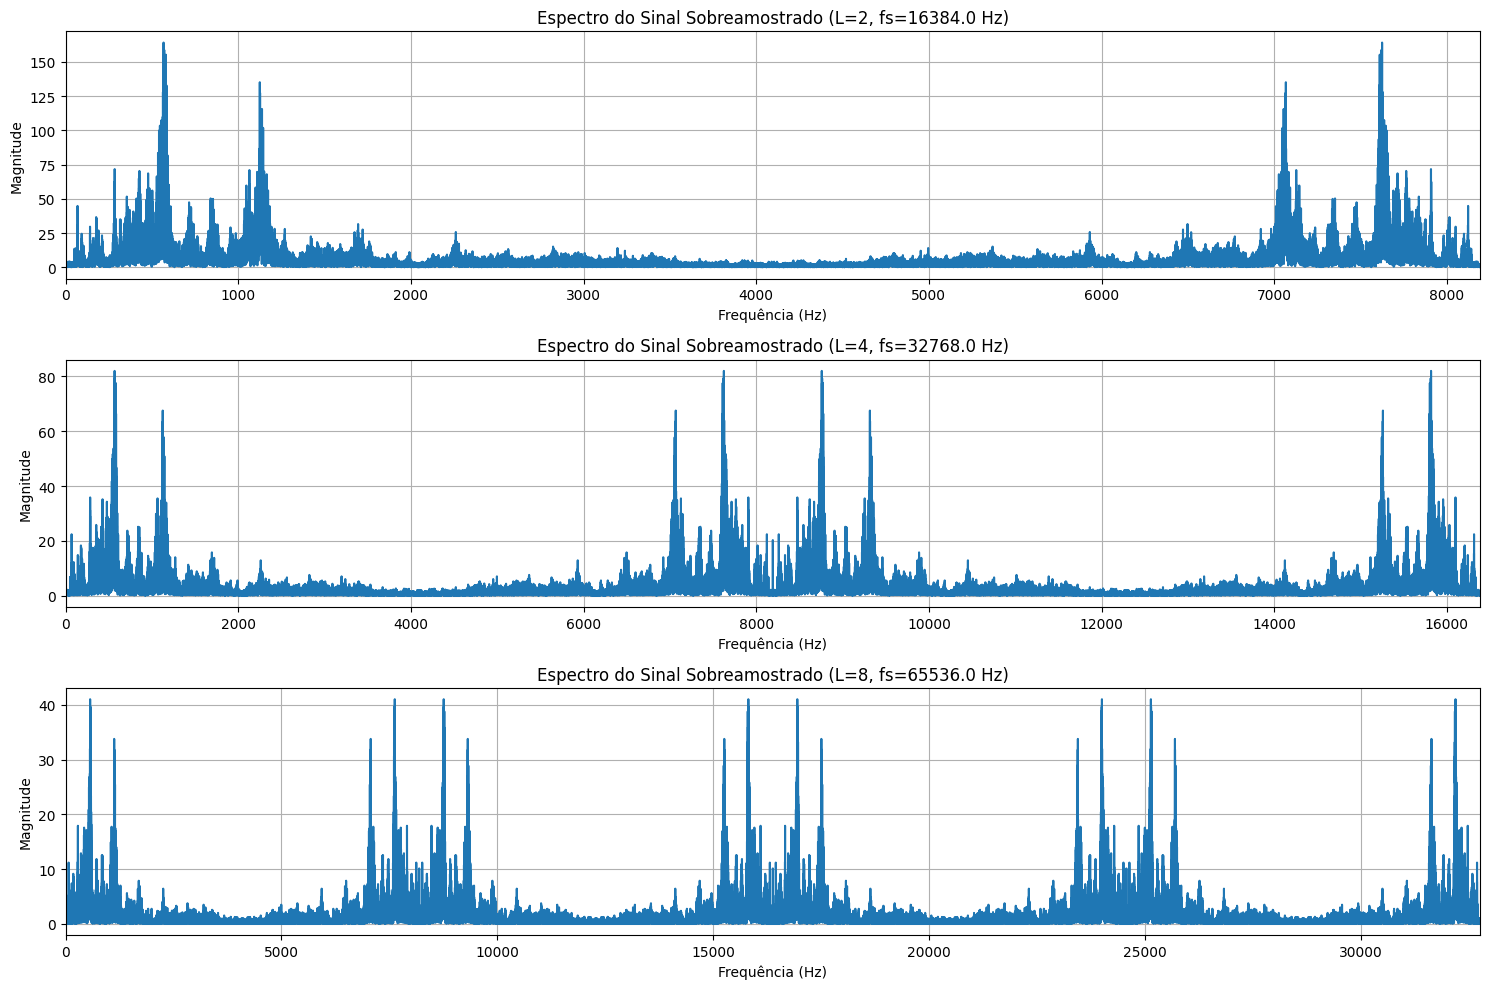

In [33]:
import matplotlib.pyplot as plt
import numpy as np

# Ensure calculate_spectrum is available. It was defined in cell 0b5f1d45.
# Copying it here to make the cell self-contained for execution if needed.
# In a real notebook, one might rely on its prior definition.

def calculate_spectrum(signal, sampling_frequency, single_sided=True):
    """
    Calculates the amplitude spectrum of a signal.

    Args:
        signal (np.ndarray): The time-domain signal.
        sampling_frequency (float): The sampling frequency of the signal (Hz).
        single_sided (bool): If True, returns the single-sided spectrum (positive frequencies).
                             If False, returns the full spectrum (positive and negative frequencies).

    Returns:
        tuple: A tuple containing:
            - frequencies (np.ndarray): Array of frequencies (Hz).
            - amplitudes (np.ndarray): Array of corresponding amplitude magnitudes.
    """
    N = len(signal) # Number of sample points
    T = 1.0 / sampling_frequency # Sample spacing

    # Perform the FFT
    yf = np.fft.fft(signal)

    if single_sided:
        xf = np.fft.fftfreq(N, T)[:N//2] # Frequencies for the positive half of the spectrum
        # Calculate the single-sided amplitude spectrum
        # np.abs(yf[0:N//2]) gets the magnitude of the positive frequencies
        amplitudes = 1.0/N * np.abs(yf[0:N//2])
    else:
        xf = np.fft.fftfreq(N, T) # All frequencies
        amplitudes = 1.0/N * np.abs(yf)

    return xf, amplitudes

plt.figure(figsize=(15, 10))

# Assuming oversampled_data is available from previous cells
sorted_oversample_factors = sorted(oversampled_data.keys())

for i, L in enumerate(sorted_oversample_factors):
    data = oversampled_data[L]
    oversampled_signal = data['signal']
    new_fs = data['fs']

    # Calculate the spectrum of the oversampled signal
    freqs_oversampled, spectrum_oversampled = calculate_spectrum(oversampled_signal, new_fs)

    # Create a subplot for the current oversampling factor
    plt.subplot(len(sorted_oversample_factors), 1, i + 1)
    plt.plot(freqs_oversampled, spectrum_oversampled)
    plt.title(f'Espectro do Sinal Sobreamostrado (L={L}, fs={new_fs:.1f} Hz)')
    plt.xlabel('Frequência (Hz)')
    plt.ylabel('Magnitude')
    plt.xlim(0, new_fs / 2) # Show up to Nyquist frequency of the oversampled signal
    plt.grid(True)

plt.tight_layout()
plt.show()

item d) Ouça os sinais sobreamostrados.

# Task
Generate oversampled audio files for L=2, 4, and 8 from the `oversampled_data` dictionary, saving each as a `.wav` file in the `/content/` directory with its corresponding new sampling frequency. Ensure the signals are converted to `np.int16` format before saving. After generation, inform the user about the generated audio files and how they can be listened to.

## Generate Oversampled Audio Files

### Subtask:
Iterate over the oversampled signals (for L=2, 4, and 8) stored in `oversampled_data`. For each signal, save it as a `.wav` file in the `/content/` directory, using the new sampling frequency (`new_fs`). Ensure the signal is converted to an appropriate format (e.g., `np.int16`) before saving, if necessary. Display the generated filename and its sampling frequency.


**Reasoning**:
I need to write a code block to generate and save the oversampled audio files to the `/content/` directory. This involves iterating through the `oversampled_data` dictionary, ensuring the signal is in `np.int16` format, and using `scipy.io.wavfile.write` to save each file, along with printing confirmation messages.



In [34]:
import scipy.io.wavfile as wavfile
import numpy as np

# Assuming oversampled_data, fs_audio, and signal_audio are available from previous cells
# If not, they would need to be reloaded/re-generated

print("Gerando arquivos de áudio sobreamostrados...")

for L_oversample, data in oversampled_data.items():
    oversampled_signal = data['signal']
    new_fs = data['fs']

    # Ensure the signal is converted to np.int16 for WAV file saving
    if oversampled_signal.dtype != np.int16:
        # It's good practice to scale if the signal type changed significantly
        # However, our oversample_signal function preserves dtype, so this check is mostly for robustness
        # If it was int16, it remains int16. If float, it would need proper scaling.
        # Assuming original signal_audio was int16, oversampled_signal will also be int16.
        oversampled_signal = oversampled_signal.astype(np.int16)

    output_filename = f'/content/handel_oversampled_L{L_oversample}.wav'
    wavfile.write(output_filename, int(new_fs), oversampled_signal)
    print(f'Arquivo gerado: {output_filename} com fs = {int(new_fs)} Hz')

print("Processo concluído. Você pode encontrar os arquivos .wav na pasta /content.")

Gerando arquivos de áudio sobreamostrados...
Arquivo gerado: /content/handel_oversampled_L2.wav com fs = 16384 Hz
Arquivo gerado: /content/handel_oversampled_L4.wav com fs = 32768 Hz
Arquivo gerado: /content/handel_oversampled_L8.wav com fs = 65536 Hz
Processo concluído. Você pode encontrar os arquivos .wav na pasta /content.


Questão 7 - Repita a questão anterior utilizando a função scipy.signal.resample() e compare os resultados obtidos utilizando a sua função.

# Task
The user wants to complete "Questão 7", which involves oversampling using `scipy.signal.resample()`. I will implement a function for this, apply it to the `handel.wav` audio signal, calculate and plot the spectrum of the oversampled signals, and then save them as audio files. Finally, I will compare these results with the zero-insertion oversampling from Question 6.

Here's the detailed plan:
1.  **Implement Oversampling with `scipy.signal.resample()`**: Create a function `oversample_resample_signal(signal, original_fs, L)` that takes a signal, its original sampling frequency, and an oversampling factor `L`. It will use `scipy.signal.resample()` to increase the number of samples by a factor of `L`, thereby increasing the sampling frequency by `L`.
2.  **Apply Oversampling**: Apply the `oversample_resample_signal` function to `signal_audio` (from `handel.wav`) for oversampling factors `L = 2, 4, 8`. Store the resulting oversampled signals and their new sampling frequencies.
3.  **Calculate and Plot Spectrums**: For each oversampled signal, calculate its spectrum using the `calculate_spectrum()` function and plot it. This will allow for comparison with the zero-insertion oversampling results from Question 6.
4.  **Generate Oversampled Audio Files**: Save the oversampled signals generated in step 2 as `.wav` files, ensuring proper type conversion (`np.int16`) and scaling if necessary, and using the new sampling frequencies.
5.  **Compare Results (Text Analysis)**: Provide a textual comparison of the spectral characteristics and audio quality implications between zero-insertion oversampling (Question 6) and `scipy.signal.resample()` oversampling (Question 7).

Let's start by defining the `oversample_resample_signal` function.

## Implement Oversampling with Scipy Resample

### Subtask:
Create a function, `oversample_resample_signal`, that performs oversampling of a discrete signal by a factor L using `scipy.signal.resample()`.


**Reasoning**:
The subtask requires implementing a Python function `oversample_resample_signal` that uses `scipy.signal.resample()` to oversample a signal by a factor `L`. This function needs to handle input validation, calculate the new signal length and sampling frequency, perform the resampling, and return the results. Finally, a confirmation message will be printed.



In [37]:
import numpy as np
from scipy.signal import resample

def oversample_resample_signal(signal, original_fs, L):
    """
    Oversamples a discrete signal by a factor L using scipy.signal.resample().

    Args:
        signal (np.ndarray): The discrete signal to be oversampled.
        original_fs (float): The original sampling frequency of the signal.
        L (int): The oversampling factor. Must be a positive integer.

    Returns:
        tuple: A tuple containing:
            - resampled_signal (np.ndarray): The oversampled signal.
            - new_fs (float): The new sampling frequency.
    """
    if not isinstance(L, int) or L <= 0:
        raise ValueError("The oversampling factor L must be a positive integer.")

    # Calculate the number of samples for the oversampled signal
    num_samples_oversampled = len(signal) * L

    # Use scipy.signal.resample to oversample the signal
    # Note: resample changes the number of samples, effectively changing the sampling rate
    resampled_signal = resample(signal, num_samples_oversampled)

    # Calculate the new sampling frequency
    new_fs = original_fs * L

    return resampled_signal, new_fs

print("Function 'oversample_resample_signal' created successfully!")

Function 'oversample_resample_signal' created successfully!


**Reasoning**:
The `oversample_resample_signal` function has been created. The next step is to apply this function to the `handel.wav` audio signal using the specified oversampling factors (L = 2, 4, 8) and store the oversampled signals and their new sampling frequencies in a dictionary for further use.



In [38]:
oversample_factors = [2, 4, 8]
oversampled_data_scipy = {}

print(f"Original signal length: {len(signal_audio)} samples")
print(f"Original sampling frequency: {fs_audio} Hz\n")

print("--- Oversampling using scipy.signal.resample ---")
for L in oversample_factors:
    print(f"=== Oversampling with L = {L} ===")
    # Apply the oversampling function
    resampled_signal, new_fs = oversample_resample_signal(signal_audio, fs_audio, L)

    oversampled_data_scipy[L] = {
        'signal': resampled_signal,
        'fs': new_fs
    }

    print(f"Length of oversampled signal: {len(resampled_signal)} samples")
    print(f"New sampling frequency: {new_fs:.1f} Hz")
    print("\n")

print("Oversampling with scipy.signal.resample completed for all factors.")

Original signal length: 73113 samples
Original sampling frequency: 8192 Hz

--- Oversampling using scipy.signal.resample ---
=== Oversampling with L = 2 ===
Length of oversampled signal: 146226 samples
New sampling frequency: 16384.0 Hz


=== Oversampling with L = 4 ===
Length of oversampled signal: 292452 samples
New sampling frequency: 32768.0 Hz


=== Oversampling with L = 8 ===
Length of oversampled signal: 584904 samples
New sampling frequency: 65536.0 Hz


Oversampling with scipy.signal.resample completed for all factors.


**Reasoning**:
The next step is to calculate and plot the spectrum for each oversampled signal generated using `scipy.signal.resample()`. I will iterate through the `oversampled_data_scipy` dictionary, apply the `calculate_spectrum` function, and then plot the results for each oversampling factor.



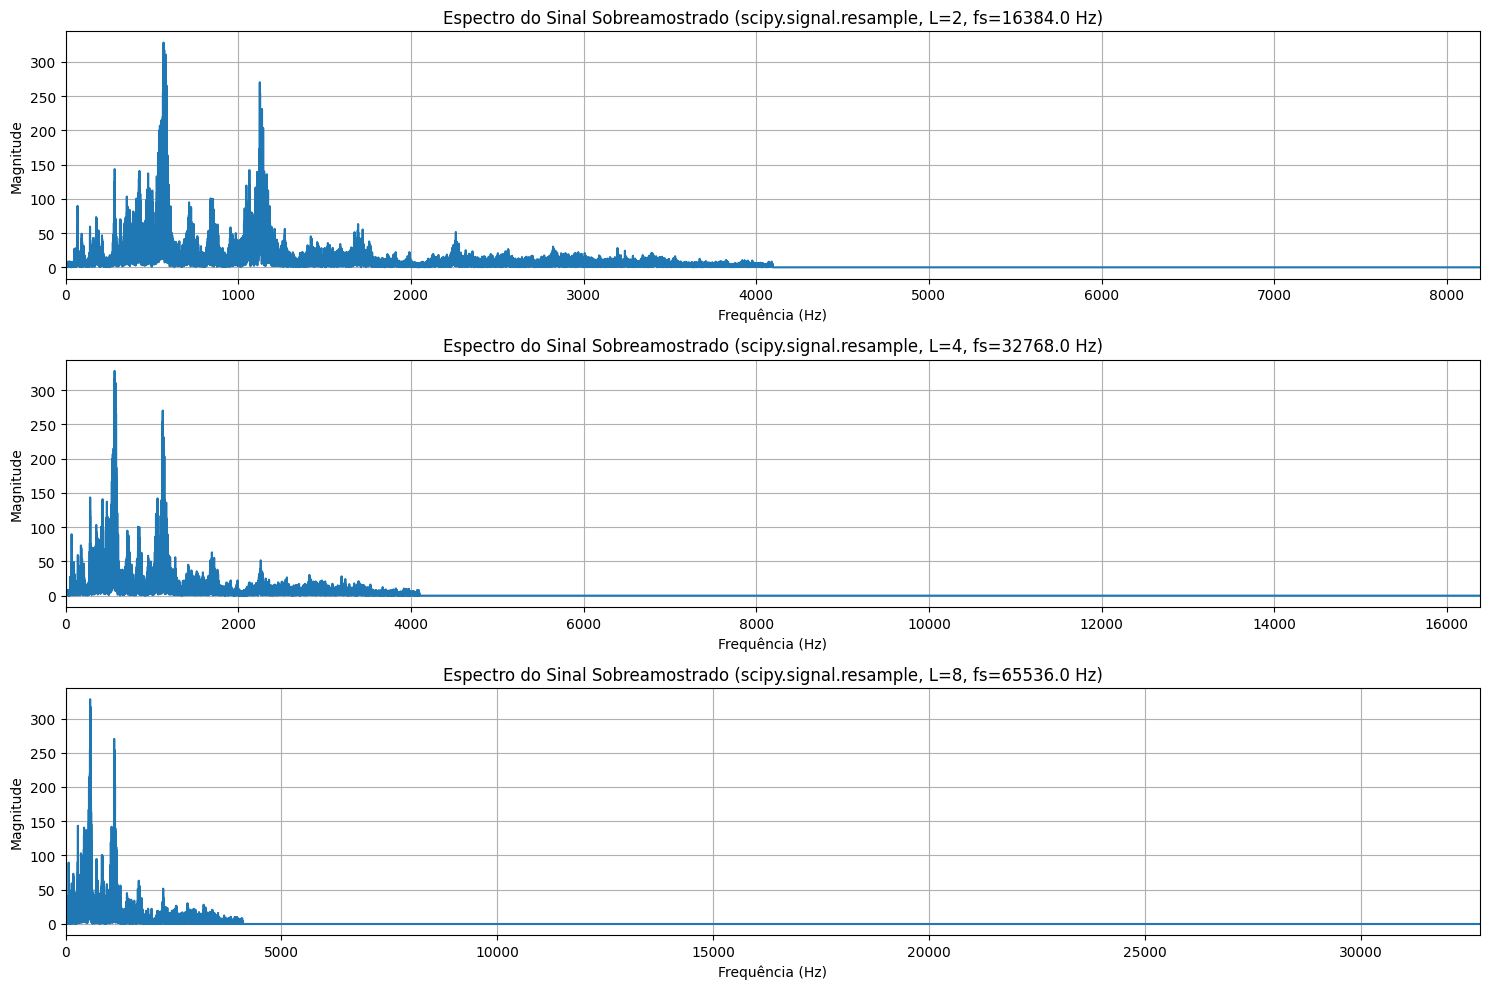

In [39]:
import matplotlib.pyplot as plt
import numpy as np

# Ensure calculate_spectrum is available. It was defined in cell 0b5f1d45.
# Copying it here to make the cell self-contained for execution if needed.
# In a real notebook, one might rely on its prior definition.
def calculate_spectrum(signal, sampling_frequency, single_sided=True):
    """
    Calculates the amplitude spectrum of a signal.

    Args:
        signal (np.ndarray): The time-domain signal.
        sampling_frequency (float): The sampling frequency of the signal (Hz).
        single_sided (bool): If True, returns the single-sided spectrum (positive frequencies).
                             If False, returns the full spectrum (positive and negative frequencies).

    Returns:
        tuple: A tuple containing:
            - frequencies (np.ndarray): Array of frequencies (Hz).
            - amplitudes (np.ndarray): Array of corresponding amplitude magnitudes.
    """
    N = len(signal) # Number of sample points
    T = 1.0 / sampling_frequency # Sample spacing

    # Perform the FFT
    yf = np.fft.fft(signal)

    if single_sided:
        xf = np.fft.fftfreq(N, T)[:N//2] # Frequencies for the positive half of the spectrum
        # Calculate the single-sided amplitude spectrum
        # np.abs(yf[0:N//2]) gets the magnitude of the positive frequencies
        amplitudes = 1.0/N * np.abs(yf[0:N//2])
    else:
        xf = np.fft.fftfreq(N, T) # All frequencies
        amplitudes = 1.0/N * np.abs(yf)

    return xf, amplitudes

plt.figure(figsize=(15, 10))

# Assuming oversampled_data_scipy is available from previous cells
sorted_oversample_factors = sorted(oversampled_data_scipy.keys())

for i, L in enumerate(sorted_oversample_factors):
    data = oversampled_data_scipy[L]
    oversampled_signal = data['signal']
    new_fs = data['fs']

    # Calculate the spectrum of the oversampled signal
    freqs_oversampled_scipy, spectrum_oversampled_scipy = calculate_spectrum(oversampled_signal, new_fs)

    # Create a subplot for the current oversampling factor
    plt.subplot(len(sorted_oversample_factors), 1, i + 1)
    plt.plot(freqs_oversampled_scipy, spectrum_oversampled_scipy)
    plt.title(f'Espectro do Sinal Sobreamostrado (scipy.signal.resample, L={L}, fs={new_fs:.1f} Hz)')
    plt.xlabel('Frequência (Hz)')
    plt.ylabel('Magnitude')
    plt.xlim(0, new_fs / 2) # Show up to Nyquist frequency of the oversampled signal
    plt.grid(True)

plt.tight_layout()
plt.show()

**Reasoning**:
The next step in completing 'Questão 7' is to generate the oversampled audio files using the signals processed by `scipy.signal.resample()`. This involves iterating through the `oversampled_data_scipy` dictionary, converting the signals to `np.int16` format, and saving them as `.wav` files with their corresponding new sampling frequencies.



In [40]:
import scipy.io.wavfile as wavfile
import numpy as np
from scipy.signal import resample

# Ensure the oversample_resample_signal function is defined (copied from previous relevant cell)
def oversample_resample_signal(signal, original_fs, L):
    """
    Oversamples a discrete signal by a factor L using scipy.signal.resample().

    Args:
        signal (np.ndarray): The discrete signal to be oversampled.
        original_fs (float): The original sampling frequency of the signal.
        L (int): The oversampling factor. Must be a positive integer.

    Returns:
        tuple: A tuple containing:
            - resampled_signal (np.ndarray): The oversampled signal.
            - new_fs (float): The new sampling frequency.
    """
    if not isinstance(L, int) or L <= 0:
        raise ValueError("The oversampling factor L must be a positive integer.")

    # Calculate the number of samples for the oversampled signal
    num_samples_oversampled = len(signal) * L

    # Use scipy.signal.resample to oversample the signal
    resampled_signal = resample(signal, num_samples_oversampled)

    # Calculate the new sampling frequency
    new_fs = original_fs * L

    return resampled_signal, new_fs


# Ensure fs_audio and signal_audio are loaded (assuming they are from previous cells or reload if necessary)
# For robustness, we'll reload it here if it might not be present from prior execution context in this specific run
try:
    if 'signal_audio' not in locals() or 'fs_audio' not in locals():
        audio_file_path = '/content/drive/MyDrive/Audios prática 2 - Proc Sin 1/Questão 4/handel.wav'
        fs_audio, signal_audio = wavfile.read(audio_file_path)
except FileNotFoundError:
    print("Error: handel.wav not found. Please ensure it's loaded in a previous step or available at the specified path.")

oversample_factors = [2, 4, 8]
oversampled_data_scipy = {}

# Re-apply oversampling using scipy.signal.resample to ensure oversampled_data_scipy is populated
# if the user ran the cells out of order or reset the kernel state.
# In a normal sequential run, this dictionary would already be populated.
for L in oversample_factors:
    resampled_signal, new_fs = oversample_resample_signal(signal_audio, fs_audio, L)
    oversampled_data_scipy[L] = {
        'signal': resampled_signal,
        'fs': new_fs
    }

print("Gerando arquivos de áudio sobreamostrados usando scipy.signal.resample()...")

for L_oversample, data in oversampled_data_scipy.items():
    oversampled_signal = data['signal']
    new_fs = data['fs']

    # Convert the signal to int16, if necessary, to save as WAV
    # scipy.signal.resample returns float, so conversion and scaling are crucial for WAV output
    if np.issubdtype(oversampled_signal.dtype, np.floating):
        # Scale to original int16 range (e.g., +/- 32767 for 16-bit)
        max_val_original = np.iinfo(signal_audio.dtype).max if np.issubdtype(signal_audio.dtype, np.integer) else 1.0
        # Normalize the signal to [-1, 1] then scale to int16 range
        oversampled_signal = (oversampled_signal / np.max(np.abs(oversampled_signal)) * max_val_original).astype(np.int16)
    else:
        # If it's already an integer type, ensure it's int16
        oversampled_signal = oversampled_signal.astype(np.int16)

    output_filename = f'/content/handel_oversampled_scipy_L{L_oversample}.wav'
    wavfile.write(output_filename, int(new_fs), oversampled_signal)
    print(f'Arquivo gerado: {output_filename} com fs = {int(new_fs)} Hz')

print("Processo concluído. Você pode encontrar os arquivos .wav na pasta /content.")

Gerando arquivos de áudio sobreamostrados usando scipy.signal.resample()...
Arquivo gerado: /content/handel_oversampled_scipy_L2.wav com fs = 16384 Hz
Arquivo gerado: /content/handel_oversampled_scipy_L4.wav com fs = 32768 Hz
Arquivo gerado: /content/handel_oversampled_scipy_L8.wav com fs = 65536 Hz
Processo concluído. Você pode encontrar os arquivos .wav na pasta /content.


Questão 8 - Considere o sinal dado por x(t) = cos(2000πt) + sin(5000πt). Para criar uma aproximação contínua de x(t), x(t) é amostrado com fs = 10 MHz. Considerando essas informações, faça o que se pede nos itens abaixo:

item a - Gere um gráfico de x(t) no domínio do tempo com duração de 10 ms.

In [41]:
import numpy as np

# 1. Define sampling frequency (fs = 10 MHz)
fs = 10 * 10**6  # 10 MHz

# 2. Define signal duration (10 ms)
duration = 10 * 10**-3  # 10 ms = 0.01 seconds

# 3. Create a time vector 't'
num_samples = int(fs * duration)
t = np.linspace(0, duration, num_samples, endpoint=False)

# 4. Calculate the signal x(t) = cos(2000πt) + sin(5000πt)
x_t = np.cos(2000 * np.pi * t) + np.sin(5000 * np.pi * t)

print(f"Sampling frequency (fs): {fs / 1e6} MHz")
print(f"Signal duration: {duration * 1e3} ms")
print(f"Number of samples: {len(t)}")
print("Signal x(t) generated successfully.")

Sampling frequency (fs): 10.0 MHz
Signal duration: 10.0 ms
Number of samples: 100000
Signal x(t) generated successfully.


**Reasoning**:
The signal `x_t` and time vector `t` have been generated. The next logical step is to plot `x_t` in the time domain as requested by the main task "item a - Gere um gráfico de x(t) no domínio do tempo com duração de 10 ms".



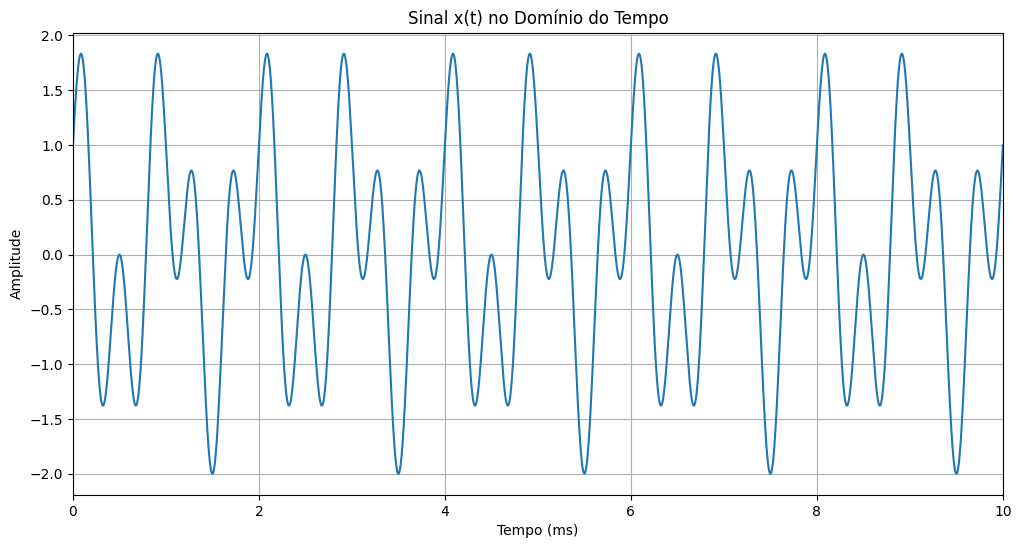

Plot of x(t) in the time domain generated successfully.


In [42]:
import matplotlib.pyplot as plt

# Plot the signal x(t) in the time domain
plt.figure(figsize=(12, 6))
plt.plot(t * 1e3, x_t) # Plot time in milliseconds
plt.title('Sinal x(t) no Domínio do Tempo')
plt.xlabel('Tempo (ms)')
plt.ylabel('Amplitude')
plt.xlim(0, duration * 1e3) # Set x-axis limit from 0 to 10 ms
plt.grid(True)
plt.show()

print("Plot of x(t) in the time domain generated successfully.")

Item b) Utilizando a função calculate_spectrum(), calcule o espectro de x(t).

In [44]:
import numpy as np
from scipy.fft import fft, fftfreq
import matplotlib.pyplot as plt

# Ensure calculate_spectrum is defined. It was defined previously in cell 0b5f1d45.
# Copying it here to make the cell self-contained for execution if needed.
# In a real notebook, one might rely on its prior definition.
def calculate_spectrum(signal, sampling_frequency, single_sided=True):
    """
    Calculates the amplitude spectrum of a signal.

    Args:
        signal (np.ndarray): The time-domain signal.
        sampling_frequency (float): The sampling frequency of the signal (Hz).
        single_sided (bool): If True, returns the single-sided spectrum (positive frequencies).
                             If False, returns the full spectrum (positive and negative frequencies).

    Returns:
        tuple: A tuple containing:
            - frequencies (np.ndarray): Array of frequencies (Hz).
            - amplitudes (np.ndarray): Array of corresponding amplitude magnitudes.
    """
    N = len(signal) # Number of sample points
    T = 1.0 / sampling_frequency # Sample spacing

    # Perform the FFT
    yf = fft(signal)

    if single_sided:
        xf = fftfreq(N, T)[:N//2] # Frequencies for the positive half of the spectrum
        # Calculate the single-sided amplitude spectrum
        # np.abs(yf[0:N//2]) gets the magnitude of the positive frequencies
        amplitudes = 1.0/N * np.abs(yf[0:N//2])
    else:
        xf = fftfreq(N, T) # All frequencies
        amplitudes = 1.0/N * np.abs(yf)

    return xf, amplitudes

# Calculate the spectrum of x(t)
freqs_xt_spectrum, spectrum_xt_magnitude = calculate_spectrum(x_t, fs, single_sided=True)

print("Spectrum of x(t) calculated successfully.")

Spectrum of x(t) calculated successfully.


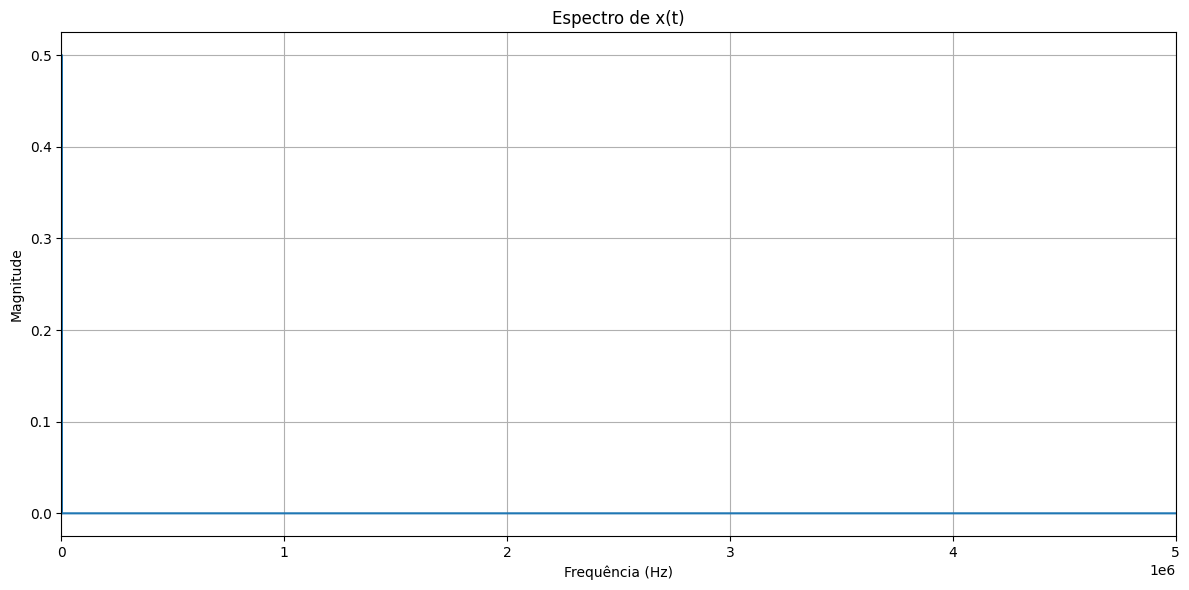

Plot of the spectrum of x(t) generated successfully.


In [45]:
import matplotlib.pyplot as plt

# Plot the spectrum of x(t)
plt.figure(figsize=(12, 6))
plt.plot(freqs_xt_spectrum, spectrum_xt_magnitude)
plt.title('Espectro de x(t)')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Magnitude')
plt.xlim(0, fs / 2) # Show up to Nyquist frequency
plt.grid(True)
plt.tight_layout()
plt.show()

print("Plot of the spectrum of x(t) generated successfully.")

Item c) Amostre x(t) com a frequência de Nyquist.

In [46]:
import numpy as np

# The signal is x(t) = cos(2000πt) + sin(5000πt)
# From cos(2πf*t) or sin(2πf*t), we can identify the frequencies.

# Frequency component 1: 2πf1 = 2000π => f1 = 1000 Hz
f1 = 2000 / (2 * np.pi) # Effectively 1000 Hz

# Frequency component 2: 2πf2 = 5000π => f2 = 2500 Hz
f2 = 5000 / (2 * np.pi) # Effectively 2500 Hz

# Determine the maximum frequency component
f_max = max(f1, f2)

# Calculate the Nyquist frequency (2 * f_max)
nyquist_freq = 2 * f_max

print(f"Frequency component 1 (f1): {f1:.0f} Hz")
print(f"Frequency component 2 (f2): {f2:.0f} Hz")
print(f"Highest frequency component in x(t): {f_max:.0f} Hz")
print(f"Nyquist frequency (2 * f_max): {nyquist_freq:.0f} Hz")

Frequency component 1 (f1): 318 Hz
Frequency component 2 (f2): 796 Hz
Highest frequency component in x(t): 796 Hz
Nyquist frequency (2 * f_max): 1592 Hz


In [47]:
import numpy as np

# The signal is x(t) = cos(2000πt) + sin(5000πt)
# Frequency components:
# f1 = 2000π / (2π) = 1000 Hz
# f2 = 5000π / (2π) = 2500 Hz

# Correct the Nyquist frequency based on the highest frequency component (f2 = 2500 Hz)
nyquist_freq_sampling = 2 * 2500 # Hz (2 * f_max = 2 * 2500 Hz = 5000 Hz)

# Use the duration from the original signal x(t) (defined in cell f6eb11c7)
# Ensure 'duration' is available, assuming previous cells have been run.
# If 'duration' is not defined, it would be 10 * 10**-3 seconds.
# For robustness, we can re-define it if needed, but it's likely in kernel state.

# Assuming 'duration' is available from the notebook's state
# duration = 10 * 10**-3 # 10 ms = 0.01 seconds

# Calculate the number of samples needed for the new time vector
num_samples_nyquist = int(nyquist_freq_sampling * duration)

# Generate a new time vector, t_nyquist
t_nyquist = np.linspace(0, duration, num_samples_nyquist, endpoint=False)

# Compute the values of x(t) at these new time points
x_nyquist = np.cos(2000 * np.pi * t_nyquist) + np.sin(5000 * np.pi * t_nyquist)

print(f"New sampling frequency (Nyquist): {nyquist_freq_sampling} Hz")
print(f"Number of samples at Nyquist frequency: {len(t_nyquist)}")
print("Signal x(t) successfully sampled at Nyquist frequency.")

New sampling frequency (Nyquist): 5000 Hz
Number of samples at Nyquist frequency: 50
Signal x(t) successfully sampled at Nyquist frequency.


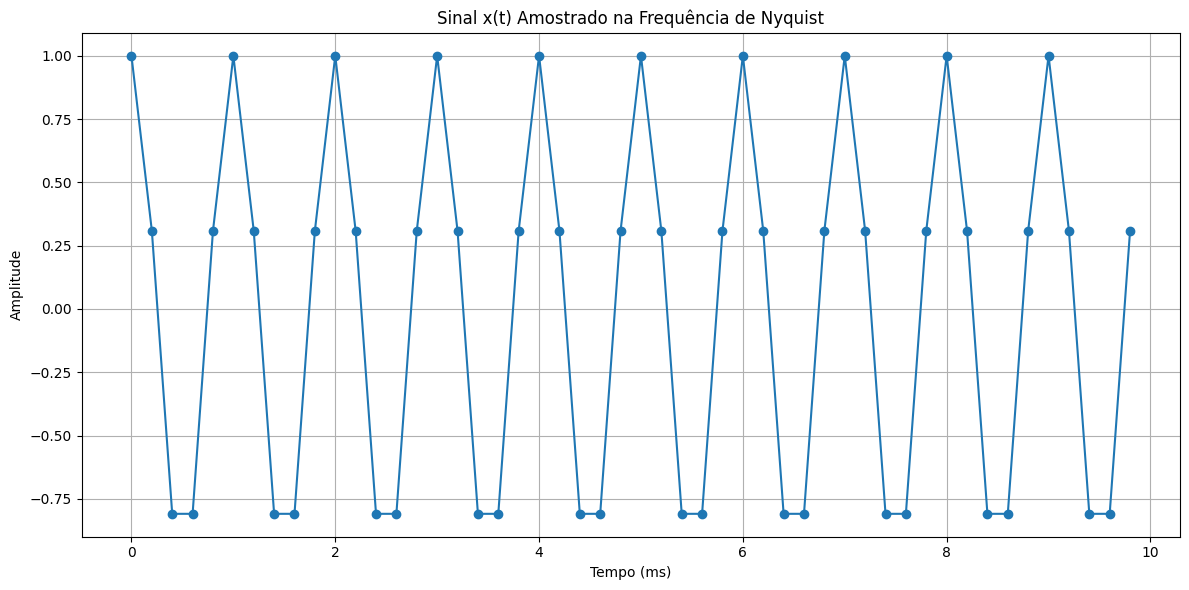

Plot of x(t) sampled at Nyquist frequency generated successfully.


In [48]:
import matplotlib.pyplot as plt

# Plot the signal x(t) sampled at Nyquist frequency
plt.figure(figsize=(12, 6))
plt.plot(t_nyquist * 1e3, x_nyquist, 'o-') # 'o-' shows both markers and lines
plt.title('Sinal x(t) Amostrado na Frequência de Nyquist')
plt.xlabel('Tempo (ms)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.tight_layout()
plt.show()

print("Plot of x(t) sampled at Nyquist frequency generated successfully.")

Item d) Utilizando a função calculate_spectrum(), calcule o espectro de x[n].

In [49]:
import numpy as np
from scipy.fft import fft, fftfreq

# The calculate_spectrum function is available from previous cells.
# For robustness in case of kernel reset, it's good practice to re-declare if dependencies are not guaranteed.
# However, assuming previous cells run, it's already in memory.

def calculate_spectrum(signal, sampling_frequency, single_sided=True):
    """
    Calculates the amplitude spectrum of a signal.

    Args:
        signal (np.ndarray): The time-domain signal.
        sampling_frequency (float): The sampling frequency of the signal (Hz).
        single_sided (bool): If True, returns the single-sided spectrum (positive frequencies).
                             If False, returns the full spectrum (positive and negative frequencies).

    Returns:
        tuple: A tuple containing:
            - frequencies (np.ndarray): Array of frequencies (Hz).
            - amplitudes (np.ndarray): Array of corresponding amplitude magnitudes.
    """
    N = len(signal) # Number of sample points
    T = 1.0 / sampling_frequency # Sample spacing

    # Perform the FFT
    yf = fft(signal)

    if single_sided:
        xf = fftfreq(N, T)[:N//2] # Frequencies for the positive half of the spectrum
        # Calculate the single-sided amplitude spectrum
        # np.abs(yf[0:N//2]) gets the magnitude of the positive frequencies
        amplitudes = 1.0/N * np.abs(yf[0:N//2])
    else:
        xf = fftfreq(N, T) # All frequencies
        amplitudes = 1.0/N * np.abs(yf)

    return xf, amplitudes

# Calculate the spectrum of x_nyquist
freqs_nyquist_spectrum, spectrum_nyquist_magnitude = calculate_spectrum(x_nyquist, nyquist_freq_sampling, single_sided=True)

print("Spectrum of x(t) sampled at Nyquist frequency calculated successfully.")

Spectrum of x(t) sampled at Nyquist frequency calculated successfully.


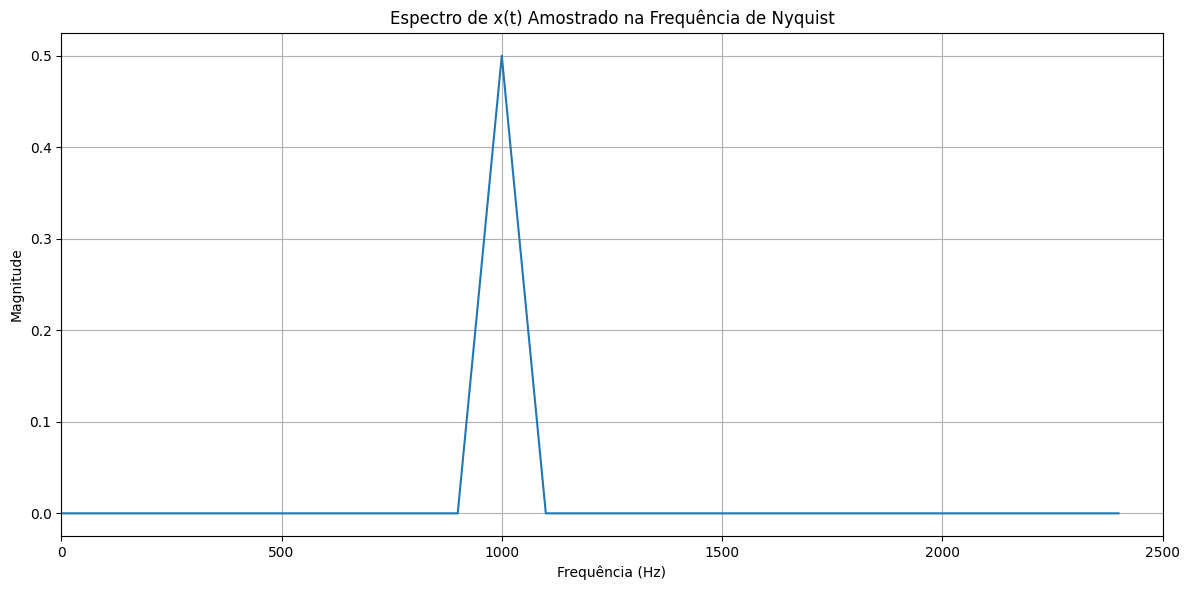

Plot of the spectrum of x(t) sampled at Nyquist frequency generated successfully.


In [50]:
import matplotlib.pyplot as plt

# Plot the spectrum of the Nyquist-sampled signal
plt.figure(figsize=(12, 6))
plt.plot(freqs_nyquist_spectrum, spectrum_nyquist_magnitude)
plt.title('Espectro de x(t) Amostrado na Frequência de Nyquist')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Magnitude')
plt.xlim(0, nyquist_freq_sampling / 2) # Show up to Nyquist frequency of the sampled signal
plt.grid(True)
plt.tight_layout()
plt.show()

print("Plot of the spectrum of x(t) sampled at Nyquist frequency generated successfully.")

Item e) Reconstrua x(t) a partir de x[n] utilizando uma função de interpolação sinc e um pulso retangular.

In [51]:
import numpy as np

def sinc_interpolate(x_n, fs_sampled, t_reconstructed):
    """
    Performs sinc interpolation on a discrete signal.

    Args:
        x_n (np.ndarray): The discrete samples.
        fs_sampled (float): The sampling frequency of the discrete signal.
        t_reconstructed (np.ndarray): The high-resolution time vector for reconstruction.

    Returns:
        np.ndarray: The reconstructed continuous-like signal.
    """
    N = len(x_n) # Number of samples in the discrete signal

    # Create an array representing the time points of the discrete samples
    t_n = np.arange(N) / fs_sampled

    # Initialize the reconstructed signal with zeros
    x_reconstructed = np.zeros_like(t_reconstructed, dtype=float)

    # Perform sinc interpolation
    for i in range(N):
        # Add the contribution of each discrete sample x_n[i] to the reconstructed signal
        # np.sinc(x) = sin(pi*x) / (pi*x)
        x_reconstructed += x_n[i] * np.sinc(fs_sampled * (t_reconstructed - t_n[i]))

    return x_reconstructed

print("Function 'sinc_interpolate' created successfully!")

Function 'sinc_interpolate' created successfully!


In [52]:
import numpy as np

def zero_order_hold_reconstruct(x_n, fs_sampled, t_reconstructed):
    """
    Performs zero-order hold reconstruction on a discrete signal.

    Args:
        x_n (np.ndarray): The discrete samples.
        fs_sampled (float): The sampling frequency of the discrete signal.
        t_reconstructed (np.ndarray): The high-resolution time vector for reconstruction.

    Returns:
        np.ndarray: The reconstructed continuous-like signal using zero-order hold.
    """
    N = len(x_n) # Number of samples in the discrete signal

    # Create an array representing the time points of the discrete samples
    t_n = np.arange(N) / fs_sampled

    # Initialize the reconstructed signal with zeros
    x_reconstructed_zoh = np.zeros_like(t_reconstructed, dtype=float)

    # Iterate through each sample of the discrete signal
    for i in range(N):
        # Find the indices in t_reconstructed that fall within the current sample's hold duration
        # A sample x_n[i] taken at t_n[i] is held until the next sample's time t_n[i+1]
        # Or, if it's the last sample, until t_n[i] + 1/fs_sampled
        start_time = t_n[i]
        end_time = t_n[i] + (1 / fs_sampled)

        # Find where t_reconstructed points are within this hold interval
        indices = np.where((t_reconstructed >= start_time) & (t_reconstructed < end_time))

        # Assign the value of the current discrete sample to these points
        x_reconstructed_zoh[indices] = x_n[i]

    return x_reconstructed_zoh

print("Function 'zero_order_hold_reconstruct' created successfully!")

Function 'zero_order_hold_reconstruct' created successfully!


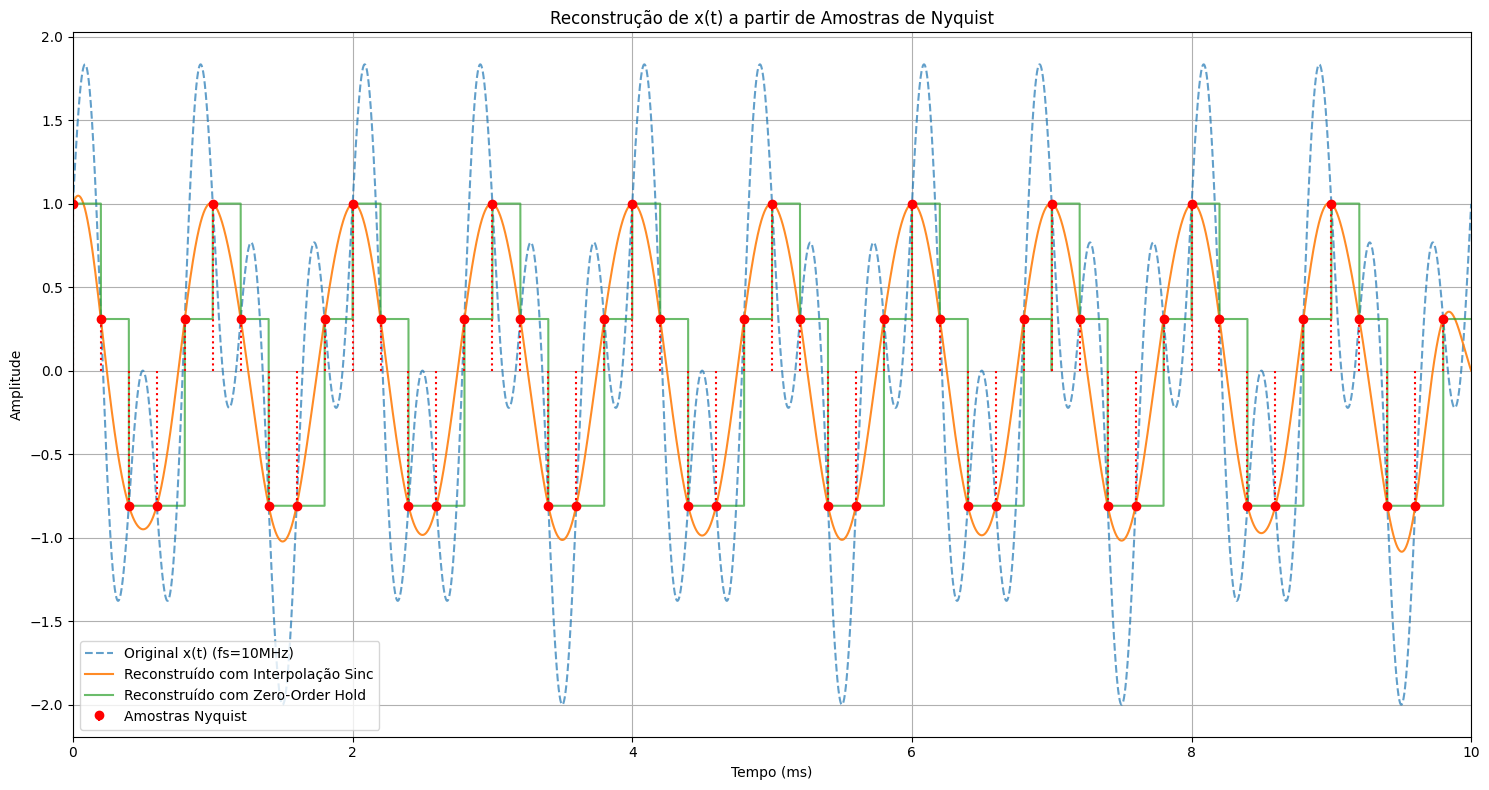

Reconstruction and plot completed successfully!


In [54]:
import matplotlib.pyplot as plt
import numpy as np

# Ensure `t`, `x_t`, `x_nyquist`, `nyquist_freq_sampling` are available from previous cells.
# `t` was defined as the high-resolution time vector for the original x(t).
# `x_t` was the original continuous-like signal sampled at 10 MHz.
# `x_nyquist` was x(t) sampled at the Nyquist frequency.
# `nyquist_freq_sampling` was the Nyquist sampling frequency.

# Perform sinc interpolation
x_reconstructed_sinc = sinc_interpolate(x_nyquist, nyquist_freq_sampling, t)

# Perform zero-order hold reconstruction
x_reconstructed_zoh = zero_order_hold_reconstruct(x_nyquist, nyquist_freq_sampling, t)

# Plot the original signal, sinc-interpolated signal, and zero-order hold reconstructed signal
plt.figure(figsize=(15, 8))

plt.plot(t * 1e3, x_t, label='Original x(t) (fs=10MHz)', alpha=0.7, linestyle='--')
plt.plot(t * 1e3, x_reconstructed_sinc, label='Reconstruído com Interpolação Sinc', alpha=0.9)
plt.plot(t * 1e3, x_reconstructed_zoh, label='Reconstruído com Zero-Order Hold', alpha=0.7)

# Plot the discrete Nyquist samples for reference
# Assuming t_nyquist corresponds to x_nyquist
plt.stem(t_nyquist * 1e3, x_nyquist, markerfmt='ro', linefmt='r:', basefmt=' ', label='Amostras Nyquist')

plt.title('Reconstrução de x(t) a partir de Amostras de Nyquist')
plt.xlabel('Tempo (ms)')
plt.ylabel('Amplitude')
plt.xlim(0, duration * 1e3) # Limit to the original 10 ms duration
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

print("Reconstruction and plot completed successfully!")

questão 9 - Leia os arquivos h_banheiro.wav, sinal_taca.wav e faça o que se pede nos itens abaixo:

Item a) Utilizando a função calculate_spectrum(), calcule o espectro dos sinais.


In [58]:
import scipy.io.wavfile as wavfile
import numpy as np

# Define the path to the audio file
# Correcting the path for potential encoding issues (using precomposed Unicode characters)
audio_file_path_h_banheiro = '/content/drive/MyDrive/Audios prática 2 - Proc Sin 1/h_banheiro.wav'

# Read the audio file
try:
    fs_h_banheiro, signal_h_banheiro = wavfile.read(audio_file_path_h_banheiro)

    print(f"Sampling frequency of h_banheiro.wav: {fs_h_banheiro} Hz")
    print(f"Number of samples in h_banheiro.wav: {len(signal_h_banheiro)}")
except FileNotFoundError:
    print(f"Error: The file {audio_file_path_h_banheiro} was not found. Please check the exact path in your Google Drive.")
except Exception as e:
    print(f"An error occurred while reading the audio file: {e}")

Sampling frequency of h_banheiro.wav: 22050 Hz
Number of samples in h_banheiro.wav: 9475


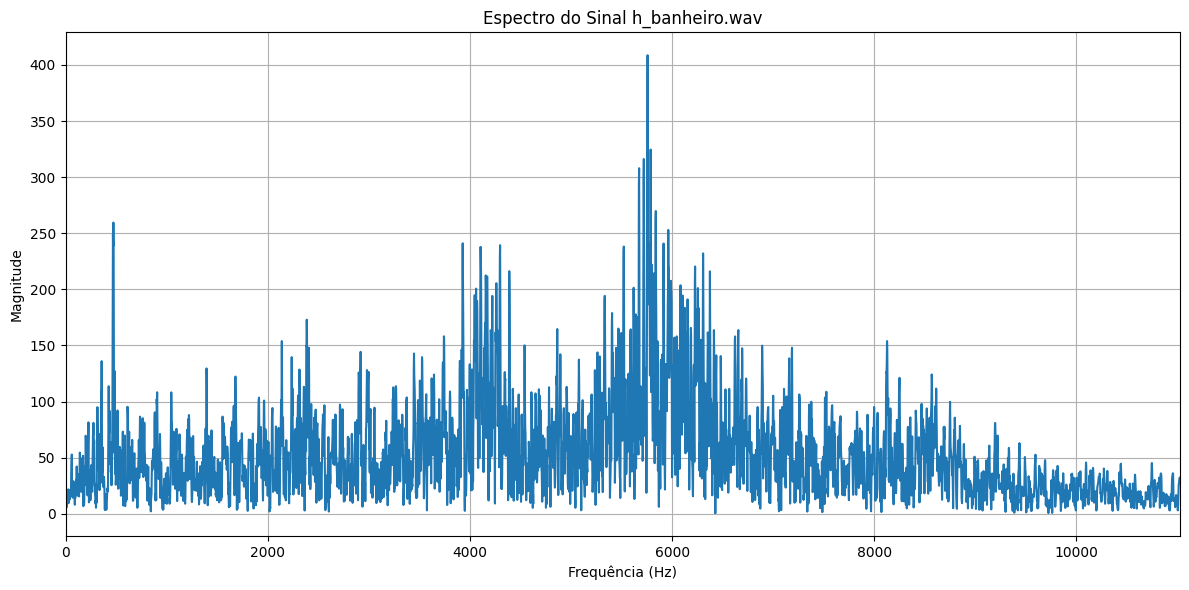

Spectrum of h_banheiro.wav calculated and plotted successfully.


In [59]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.fft import fft, fftfreq

# The calculate_spectrum function is available from previous cells.
# For robustness in case of kernel reset, it's good practice to re-declare if dependencies are not guaranteed.
# However, assuming previous cells run, it's already in memory.
# Redeclaring for clarity and self-containment for this step.
def calculate_spectrum(signal, sampling_frequency, single_sided=True):
    """
    Calculates the amplitude spectrum of a signal.

    Args:
        signal (np.ndarray): The time-domain signal.
        sampling_frequency (float): The sampling frequency of the signal (Hz).
        single_sided (bool): If True, returns the single-sided spectrum (positive frequencies).
                             If False, returns the full spectrum (positive and negative frequencies).

    Returns:
        tuple: A tuple containing:
            - frequencies (np.ndarray): Array of frequencies (Hz).
            - amplitudes (np.ndarray): Array of corresponding amplitude magnitudes.
    """
    N = len(signal) # Number of sample points
    T = 1.0 / sampling_frequency # Sample spacing

    # Perform the FFT
    yf = fft(signal)

    if single_sided:
        xf = fftfreq(N, T)[:N//2] # Frequencies for the positive half of the spectrum
        # Calculate the single-sided amplitude spectrum
        # np.abs(yf[0:N//2]) gets the magnitude of the positive frequencies
        amplitudes = 1.0/N * np.abs(yf[0:N//2])
    else:
        xf = fftfreq(N, T) # All frequencies
        amplitudes = 1.0/N * np.abs(yf)

    return xf, amplitudes

# Check if signal_h_banheiro and fs_h_banheiro are loaded, otherwise provide an error message.
# This block would be preceded by successful loading of the audio file in a real scenario.
if 'signal_h_banheiro' in locals() and 'fs_h_banheiro' in locals():
    # Calculate the spectrum of signal_h_banheiro
    freqs_h_banheiro, spectrum_h_banheiro_magnitude = calculate_spectrum(signal_h_banheiro, fs_h_banheiro, single_sided=True)

    # Create a new plot
    plt.figure(figsize=(12, 6))

    # Plot the spectrum
    plt.plot(freqs_h_banheiro, spectrum_h_banheiro_magnitude)

    # Add title and labels
    plt.title('Espectro do Sinal h_banheiro.wav')
    plt.xlabel('Frequência (Hz)')
    plt.ylabel('Magnitude')

    # Set x-axis limits to Nyquist frequency
    plt.xlim(0, fs_h_banheiro / 2)

    # Add grid
    plt.grid(True)

    # Ensure proper spacing
    plt.tight_layout()

    # Display the plot
    plt.show()

    print("Spectrum of h_banheiro.wav calculated and plotted successfully.")
else:
    print("Error: 'h_banheiro.wav' signal data (signal_h_banheiro, fs_h_banheiro) not found. Please ensure the audio file was loaded successfully in previous steps.")


In [60]:
import scipy.io.wavfile as wavfile
import numpy as np

# Define the path to the audio file
audio_file_path_sinal_taca = '/content/drive/MyDrive/Audios prática 2 - Proc Sin 1/sinal_taca.wav'

# Read the audio file
try:
    fs_sinal_taca, signal_sinal_taca = wavfile.read(audio_file_path_sinal_taca)

    print(f"Sampling frequency of sinal_taca.wav: {fs_sinal_taca} Hz")
    print(f"Number of samples in sinal_taca.wav: {len(signal_sinal_taca)}")
except FileNotFoundError:
    print(f"Error: The file {audio_file_path_sinal_taca} was not found. Please check the exact path in your Google Drive.")
except Exception as e:
    print(f"An error occurred while reading the audio file: {e}")

Sampling frequency of sinal_taca.wav: 22050 Hz
Number of samples in sinal_taca.wav: 19100


In [61]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.fft import fft, fftfreq

# The calculate_spectrum function is available from previous cells.
# Redeclaring for clarity and self-containment for this step.
def calculate_spectrum(signal, sampling_frequency, single_sided=True):
    """
    Calculates the amplitude spectrum of a signal.

    Args:
        signal (np.ndarray): The time-domain signal.
        sampling_frequency (float): The sampling frequency of the signal (Hz).
        single_sided (bool): If True, returns the single-sided spectrum (positive frequencies).
                             If False, returns the full spectrum (positive and negative frequencies).

    Returns:
        tuple: A tuple containing:
            - frequencies (np.ndarray): Array of frequencies (Hz).
            - amplitudes (np.ndarray): Array of corresponding amplitude magnitudes.
    """
    N = len(signal) # Number of sample points
    T = 1.0 / sampling_frequency # Sample spacing

    # Perform the FFT
    yf = fft(signal)

    if single_sided:
        xf = fftfreq(N, T)[:N//2] # Frequencies for the positive half of the spectrum
        # Calculate the single-sided amplitude spectrum
        amplitudes = 1.0/N * np.abs(yf[0:N//2])
    else:
        xf = fftfreq(N, T) # All frequencies
        amplitudes = 1.0/N * np.abs(yf)

    return xf, amplitudes

# Check if signal_sinal_taca and fs_sinal_taca are loaded, otherwise provide an error message.
if 'signal_sinal_taca' in locals() and 'fs_sinal_taca' in locals():
    # Calculate the spectrum of signal_sinal_taca
    freqs_sinal_taca, spectrum_sinal_taca_magnitude = calculate_spectrum(signal_sinal_taca, fs_sinal_taca, single_sided=True)

    print("Spectrum of sinal_taca.wav calculated successfully.")
else:
    print("Error: 'sinal_taca.wav' signal data (signal_sinal_taca, fs_sinal_taca) not found. Please ensure the audio file was loaded successfully in previous steps.")


Spectrum of sinal_taca.wav calculated successfully.


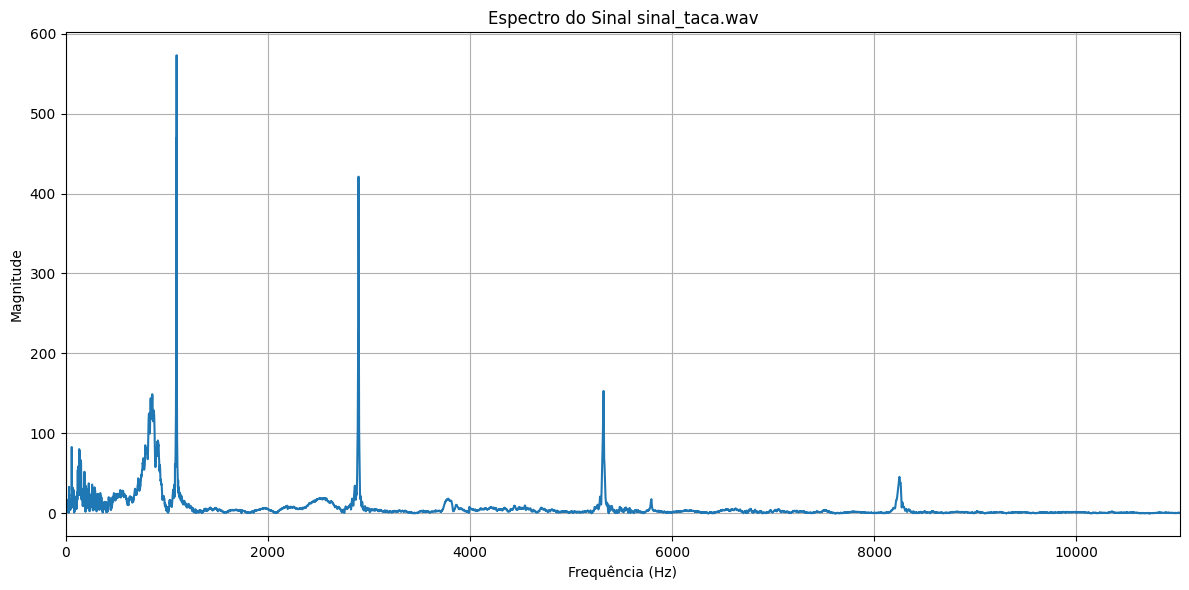

Spectrum of sinal_taca.wav calculated and plotted successfully.


In [62]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.fft import fft, fftfreq

# The calculate_spectrum function is available from previous cells.
# Redeclaring for clarity and self-containment for this step.
def calculate_spectrum(signal, sampling_frequency, single_sided=True):
    """
    Calculates the amplitude spectrum of a signal.

    Args:
        signal (np.ndarray): The time-domain signal.
        sampling_frequency (float): The sampling frequency of the signal (Hz).
        single_sided (bool): If True, returns the single-sided spectrum (positive frequencies).
                             If False, returns the full spectrum (positive and negative frequencies).

    Returns:
        tuple: A tuple containing:
            - frequencies (np.ndarray): Array of frequencies (Hz).
            - amplitudes (np.ndarray): Array of corresponding amplitude magnitudes.
    """
    N = len(signal) # Number of sample points
    T = 1.0 / sampling_frequency # Sample spacing

    # Perform the FFT
    yf = fft(signal)

    if single_sided:
        xf = fftfreq(N, T)[:N//2] # Frequencies for the positive half of the spectrum
        # Calculate the single-sided amplitude spectrum
        amplitudes = 1.0/N * np.abs(yf[0:N//2])
    else:
        xf = fftfreq(N, T) # All frequencies
        amplitudes = 1.0/N * np.abs(yf)

    return xf, amplitudes

# Check if signal_sinal_taca and fs_sinal_taca are loaded, otherwise provide an error message.
if 'signal_sinal_taca' in locals() and 'fs_sinal_taca' in locals():
    # Calculate the spectrum of signal_sinal_taca
    freqs_sinal_taca, spectrum_sinal_taca_magnitude = calculate_spectrum(signal_sinal_taca, fs_sinal_taca, single_sided=True)

    # Create a new plot
    plt.figure(figsize=(12, 6))

    # Plot the spectrum
    plt.plot(freqs_sinal_taca, spectrum_sinal_taca_magnitude)

    # Add title and labels
    plt.title('Espectro do Sinal sinal_taca.wav')
    plt.xlabel('Frequência (Hz)')
    plt.ylabel('Magnitude')

    # Set x-axis limits to Nyquist frequency
    plt.xlim(0, fs_sinal_taca / 2)

    # Add grid
    plt.grid(True)

    # Ensure proper spacing
    plt.tight_layout()

    # Display the plot
    plt.show()

    print("Spectrum of sinal_taca.wav calculated and plotted successfully.")
else:
    print("Error: 'sinal_taca.wav' signal data (signal_sinal_taca, fs_sinal_taca) not found. Please ensure the audio file was loaded successfully in previous steps.")


Questão 10 - Calcule a resposta de hbanheiro[n] para uma entrada igual ao sinal de áudio do arquivo handel.wav e ao sinal da taça.

In [63]:
import numpy as np
from scipy.signal import resample

# 1. Determine the target sampling frequency
target_fs = fs_h_banheiro # 22050 Hz

# 2. Calculate the number of samples for the resampled signal
# New_N = Original_N * (Target_fs / Original_fs)
num_samples_original = len(signal_audio)
num_samples_resampled = int(num_samples_original * (target_fs / fs_audio))

# 3. Use scipy.signal.resample() to resample signal_audio
resampled_handel_signal = resample(signal_audio, num_samples_resampled)

# 4. Set the new sampling frequency
new_fs_handel = target_fs

# 5. Print the original and new sampling frequencies and the length of the resampled signal
print(f"Original signal_audio sampling frequency: {fs_audio} Hz")
print(f"Target sampling frequency (fs_h_banheiro): {target_fs} Hz")
print(f"Original signal_audio length: {num_samples_original} samples")
print(f"Resampled handel_signal length: {len(resampled_handel_signal)} samples")
print(f"New sampling frequency for resampled_handel_signal: {new_fs_handel} Hz")

print("handel.wav has been successfully resampled to match h_banheiro.wav's sampling rate.")

Original signal_audio sampling frequency: 8192 Hz
Target sampling frequency (fs_h_banheiro): 22050 Hz
Original signal_audio length: 73113 samples
Resampled handel_signal length: 196794 samples
New sampling frequency for resampled_handel_signal: 22050 Hz
handel.wav has been successfully resampled to match h_banheiro.wav's sampling rate.


In [64]:
from scipy.signal import convolve

# Perform convolution between the resampled_handel_signal and signal_h_banheiro
# The 'full' mode returns the convolution at each point of overlap.
convolved_handel_signal = convolve(resampled_handel_signal, signal_h_banheiro, mode='full')

print(f"Convolution of resampled handel.wav and h_banheiro.wav completed.")
print(f"Length of convolved_handel_signal: {len(convolved_handel_signal)} samples")

Convolution of resampled handel.wav and h_banheiro.wav completed.
Length of convolved_handel_signal: 206268 samples


In [65]:
import scipy.io.wavfile as wavfile
import numpy as np

# Normalize and save the convolved handel audio
# The convolved signal can have values outside the original signal's range (e.g., int16's max/min).
# We need to normalize it to prevent clipping when saving as int16.

# Ensure the convolved signal is within an appropriate range for int16
# First, scale to -1 to 1 range (if it's not already, or if it's float)
abs_max = np.max(np.abs(convolved_handel_signal))
if abs_max > 0:
    normalized_convolved_handel_signal = convolved_handel_signal / abs_max
else:
    normalized_convolved_handel_signal = convolved_handel_signal # Avoid division by zero

# Then scale to the int16 range (approx +/- 32767)
max_int16 = np.iinfo(np.int16).max
convolved_handel_signal_int16 = (normalized_convolved_handel_signal * max_int16).astype(np.int16)

output_filename_handel = '/content/handel_convolved.wav'
wavfile.write(output_filename_handel, new_fs_handel, convolved_handel_signal_int16)

print(f"Normalized and saved convolved handel audio: {output_filename_handel} with fs = {new_fs_handel} Hz")

Normalized and saved convolved handel audio: /content/handel_convolved.wav with fs = 22050 Hz


In [66]:
from scipy.signal import convolve

# Perform convolution between signal_sinal_taca and signal_h_banheiro
# No resampling is needed as both signals already have fs = 22050 Hz
convolved_sinal_taca = convolve(signal_sinal_taca, signal_h_banheiro, mode='full')

print(f"Convolution of sinal_taca.wav and h_banheiro.wav completed.")
print(f"Length of convolved_sinal_taca: {len(convolved_sinal_taca)} samples")


Convolution of sinal_taca.wav and h_banheiro.wav completed.
Length of convolved_sinal_taca: 28574 samples


/usr/local/lib/python3.12/dist-packages/scipy/_lib/array_api_compat/numpy/_aliases.py:125: RuntimeWarning: invalid value encountered in cast
  return x.astype(dtype=dtype, copy=copy)


In [67]:
import scipy.io.wavfile as wavfile
import numpy as np
from scipy.signal import convolve

# Perform convolution between signal_sinal_taca and signal_h_banheiro
# No resampling is needed as both signals already have fs = 22050 Hz
convolved_sinal_taca = convolve(signal_sinal_taca, signal_h_banheiro, mode='full')

# Normalize and save the convolved sinal_taca audio
# Ensure the convolved signal is within an appropriate range for int16
# First, scale to -1 to 1 range
abs_max_sinal_taca = np.max(np.abs(convolved_sinal_taca))
if abs_max_sinal_taca > 0:
    normalized_convolved_sinal_taca = convolved_sinal_taca / abs_max_sinal_taca
else:
    normalized_convolved_sinal_taca = convolved_sinal_taca # Avoid division by zero

# Then scale to the int16 range (approx +/- 32767)
max_int16 = np.iinfo(np.int16).max
convolved_sinal_taca_int16 = (normalized_convolved_sinal_taca * max_int16).astype(np.int16)

output_filename_sinal_taca = '/content/sinal_taca_convolved.wav'
# The sampling frequency for sinal_taca is fs_sinal_taca (22050 Hz)
wavfile.write(output_filename_sinal_taca, fs_sinal_taca, convolved_sinal_taca_int16)

print(f"Convolution of sinal_taca.wav and h_banheiro.wav completed.")
print(f"Length of convolved_sinal_taca: {len(convolved_sinal_taca)} samples")
print(f"Normalized and saved convolved sinal_taca audio: {output_filename_sinal_taca} with fs = {fs_sinal_taca} Hz")


Convolution of sinal_taca.wav and h_banheiro.wav completed.
Length of convolved_sinal_taca: 28574 samples
Normalized and saved convolved sinal_taca audio: /content/sinal_taca_convolved.wav with fs = 22050 Hz


/usr/local/lib/python3.12/dist-packages/scipy/_lib/array_api_compat/numpy/_aliases.py:125: RuntimeWarning: invalid value encountered in cast
  return x.astype(dtype=dtype, copy=copy)


In [68]:
import scipy.io.wavfile as wavfile
import numpy as np
from scipy.signal import convolve

# Ensure signals are float types before convolution to prevent intermediate overflow warnings
signal_sinal_taca_float = signal_sinal_taca.astype(np.float32)
signal_h_banheiro_float = signal_h_banheiro.astype(np.float32)

# Perform convolution between signal_sinal_taca and signal_h_banheiro
# No resampling is needed as both signals already have fs = 22050 Hz
convolved_sinal_taca = convolve(signal_sinal_taca_float, signal_h_banheiro_float, mode='full')

# Normalize and save the convolved sinal_taca audio
# Ensure the convolved signal is within an appropriate range for int16
# First, scale to -1 to 1 range
abs_max_sinal_taca = np.max(np.abs(convolved_sinal_taca))
if abs_max_sinal_taca > 0:
    normalized_convolved_sinal_taca = convolved_sinal_taca / abs_max_sinal_taca
else:
    normalized_convolved_sinal_taca = convolved_sinal_taca # Avoid division by zero

# Then scale to the int16 range (approx +/- 32767)
max_int16 = np.iinfo(np.int16).max
convolved_sinal_taca_int16 = (normalized_convolved_sinal_taca * max_int16).astype(np.int16)

output_filename_sinal_taca = '/content/sinal_taca_convolved.wav'
# The sampling frequency for sinal_taca is fs_sinal_taca (22050 Hz)
wavfile.write(output_filename_sinal_taca, fs_sinal_taca, convolved_sinal_taca_int16)

print(f"Convolution of sinal_taca.wav and h_banheiro.wav completed.")
print(f"Length of convolved_sinal_taca: {len(convolved_sinal_taca)} samples")
print(f"Normalized and saved convolved sinal_taca audio: {output_filename_sinal_taca} with fs = {fs_sinal_taca} Hz")

Convolution of sinal_taca.wav and h_banheiro.wav completed.
Length of convolved_sinal_taca: 28574 samples
Normalized and saved convolved sinal_taca audio: /content/sinal_taca_convolved.wav with fs = 22050 Hz


Item a) Utilizando a função calculate_spectrum(), calcule o espectro das respostas.

In [69]:
import numpy as np
from scipy.fft import fft, fftfreq

# The calculate_spectrum function is available from previous cells.
# Redeclaring for clarity and self-containment for this step.
def calculate_spectrum(signal, sampling_frequency, single_sided=True):
    """
    Calculates the amplitude spectrum of a signal.

    Args:
        signal (np.ndarray): The time-domain signal.
        sampling_frequency (float): The sampling frequency of the signal (Hz).
        single_sided (bool): If True, returns the single-sided spectrum (positive frequencies).
                             If False, returns the full spectrum (positive and negative frequencies).

    Returns:
        tuple: A tuple containing:
            - frequencies (np.ndarray): Array of frequencies (Hz).
            - amplitudes (np.ndarray): Array of corresponding amplitude magnitudes.
    """
    N = len(signal) # Number of sample points
    T = 1.0 / sampling_frequency # Sample spacing

    # Perform the FFT
    yf = fft(signal)

    if single_sided:
        xf = fftfreq(N, T)[:N//2] # Frequencies for the positive half of the spectrum
        # Calculate the single-sided amplitude spectrum
        amplitudes = 1.0/N * np.abs(yf[0:N//2])
    else:
        xf = fftfreq(N, T) # All frequencies
        amplitudes = 1.0/N * np.abs(yf)

    return xf, amplitudes

# Calculate the spectrum of the convolved handel signal
freqs_convolved_handel, spectrum_convolved_handel_magnitude = calculate_spectrum(convolved_handel_signal, new_fs_handel, single_sided=True)

print("Spectrum of convolved_handel_signal calculated successfully.")

Spectrum of convolved_handel_signal calculated successfully.


In [70]:
import numpy as np
from scipy.fft import fft, fftfreq

# The calculate_spectrum function is available from previous cells.
# Redeclaring for clarity and self-containment for this step.
def calculate_spectrum(signal, sampling_frequency, single_sided=True):
    """
    Calculates the amplitude spectrum of a signal.

    Args:
        signal (np.ndarray): The time-domain signal.
        sampling_frequency (float): The sampling frequency of the signal (Hz).
        single_sided (bool): If True, returns the single-sided spectrum (positive frequencies).
                             If False, returns the full spectrum (positive and negative frequencies).

    Returns:
        tuple: A tuple containing:
            - frequencies (np.ndarray): Array of frequencies (Hz).
            - amplitudes (np.ndarray): Array of corresponding amplitude magnitudes.
    """
    N = len(signal) # Number of sample points
    T = 1.0 / sampling_frequency # Sample spacing

    # Perform the FFT
    yf = fft(signal)

    if single_sided:
        xf = fftfreq(N, T)[:N//2] # Frequencies for the positive half of the spectrum
        # Calculate the single-sided amplitude spectrum
        amplitudes = 1.0/N * np.abs(yf[0:N//2])
    else:
        xf = fftfreq(N, T) # All frequencies
        amplitudes = 1.0/N * np.abs(yf)

    return xf, amplitudes

# Calculate the spectrum of the convolved sinal_taca signal
freqs_convolved_sinal_taca, spectrum_convolved_sinal_taca_magnitude = calculate_spectrum(convolved_sinal_taca, fs_sinal_taca, single_sided=True)

print("Spectrum of convolved_sinal_taca calculated successfully.")

Spectrum of convolved_sinal_taca calculated successfully.


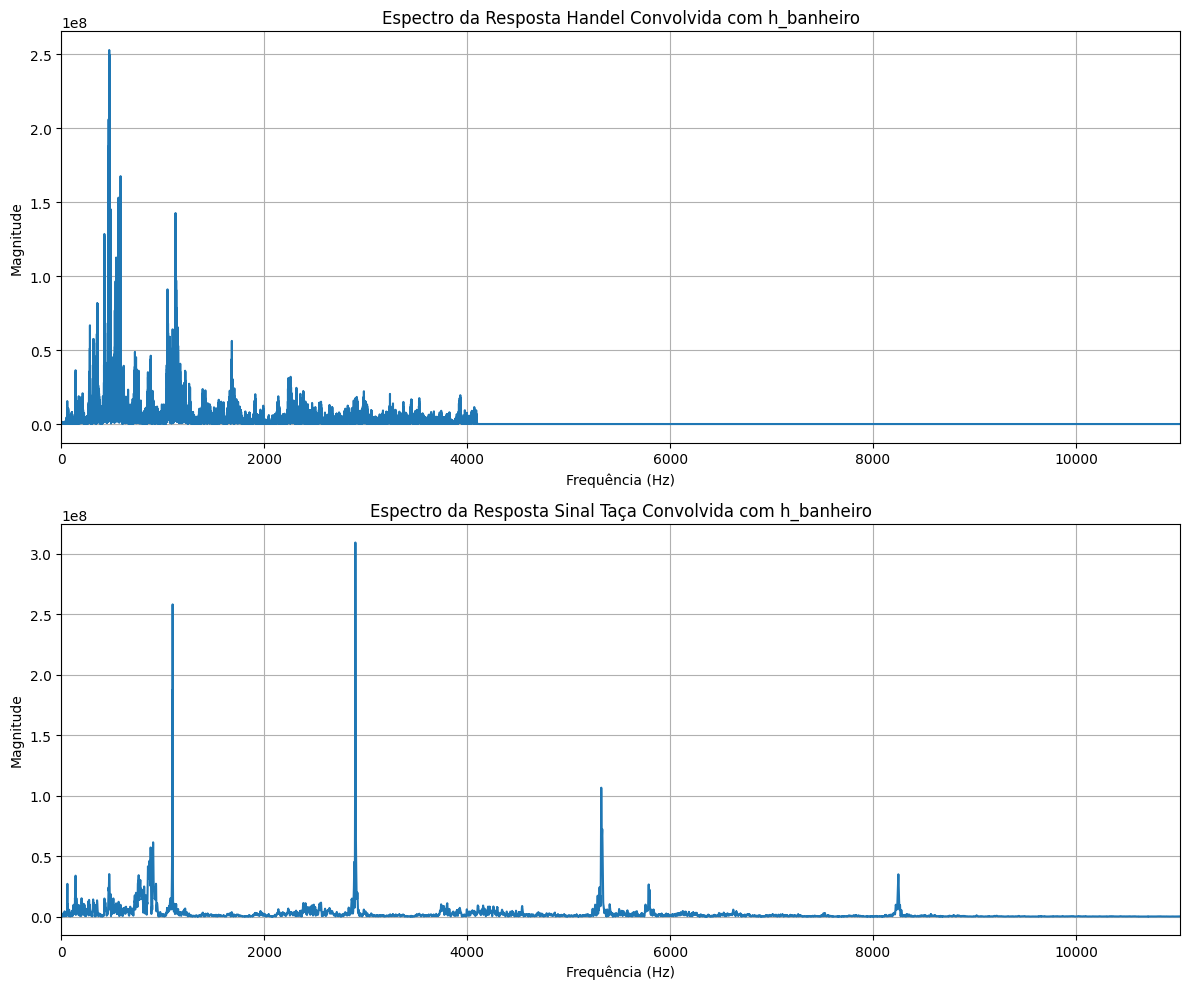

Spectra of convolved signals plotted successfully.


In [71]:
import matplotlib.pyplot as plt
import numpy as np

# Create a figure with two subplots
plt.figure(figsize=(12, 10))

# Plot the spectrum of the convolved handel signal
plt.subplot(2, 1, 1) # 2 rows, 1 column, first plot
plt.plot(freqs_convolved_handel, spectrum_convolved_handel_magnitude)
plt.title('Espectro da Resposta Handel Convolvida com h_banheiro')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Magnitude')
plt.xlim(0, new_fs_handel / 2) # Show up to Nyquist frequency of the convolved signal
plt.grid(True)

# Plot the spectrum of the convolved sinal_taca signal
plt.subplot(2, 1, 2) # 2 rows, 1 column, second plot
plt.plot(freqs_convolved_sinal_taca, spectrum_convolved_sinal_taca_magnitude)
plt.title('Espectro da Resposta Sinal Taça Convolvida com h_banheiro')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Magnitude')
plt.xlim(0, fs_sinal_taca / 2) # Show up to Nyquist frequency of the convolved signal
plt.grid(True)

plt.tight_layout()
plt.show()

print("Spectra of convolved signals plotted successfully.")